# Credit risk scoring

**Domain**: Finance / Banking

**Type**: ML — Classification + Fairness

*Problem* 

A bank needs to decide whether to approve loan applications. Build a scoring model that predicts 
the probability of default. This project introduces real-world constraints: interpretability 
requirements, regulatory fairness, and business asymmetry — approving a bad loan and rejecting a 
good one are not equal mistakes. 

*Dataset* 

● German Credit Risk — [UCI Machine Learning Repository ](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) loaded and then manually adjusted according to 
[South German Credit Risk](https://www1.beuth-hochschule.de/FB_II/reports/Report-2019-004.pdf)

● 1,000 applicants, 20 features

● Binary target: good (700) vs bad credit (300) 

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.tree import (
    DecisionTreeClassifier, plot_tree, export_text
)

In [2]:
notebook_start = time.time()

### Load + cleanup

In [10]:
#correct shape [1000 rows x 21 columns]
df = pd.read_csv('data\german.data',
                sep=' ',
                #header=None,
                index_col=False,
                names=['status','duration','credit_history','purpose','amount','savings','employment_duration',
                       'installment_rate','personal_status_sex','other_debtors','present_residence','property','age',
                       'other_installment_plans','housing','number_credits','job','people_liable','telephone',
                       'foreign_worker','credit_risk']
                  )
print(df)

    status  duration credit_history purpose  amount savings  \
0      A11         6            A34     A43    1169     A65   
1      A12        48            A32     A43    5951     A61   
2      A14        12            A34     A46    2096     A61   
3      A11        42            A32     A42    7882     A61   
4      A11        24            A33     A40    4870     A61   
..     ...       ...            ...     ...     ...     ...   
995    A14        12            A32     A42    1736     A61   
996    A11        30            A32     A41    3857     A61   
997    A14        12            A32     A43     804     A61   
998    A11        45            A32     A43    1845     A61   
999    A12        45            A34     A41    4576     A62   

    employment_duration  installment_rate personal_status_sex other_debtors  \
0                   A75                 4                 A93          A101   
1                   A73                 2                 A92          A101   
2     

<>:2: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:2: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\sstoj\AppData\Local\Temp\ipykernel_10308\2889832531.py:2: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  df = pd.read_csv('data\german.data',


In [78]:
y = df['credit_risk'].map({1:'good' ,2:'bad'})

In [79]:
y.value_counts()

credit_risk
good    700
bad     300
Name: count, dtype: int64

In [80]:
df['credit_risk'] = df['credit_risk'].map({2:0,1:1})

In [81]:
df['credit_risk'].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

## I EDA

In [82]:
df.columns
#as provided when loading

Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings',
       'employment_duration', 'installment_rate', 'personal_status_sex',
       'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job',
       'people_liable', 'telephone', 'foreign_worker', 'credit_risk'],
      dtype='str')

In [ ]:
df.info()
#3 numerical, 18 categorical - we will correct these manually

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

In [84]:
#missing values, can also be seen above
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [85]:
#full duplicate check
df.duplicated().value_counts()

False    1000
Name: count, dtype: int64

### Initial analysis by column

Attribute 1:  status (qualitative) A1

	       Status of the debtor's checking account with the bank
		   1 : no checking account
		   2 : ... < 0 DM
		   3 : 0<= ... < 200 DM
		   4 : ... >= 200 DM / salary for at least 1 year

In [86]:
df['status'] = df['status'].map({'A11':1 ,'A12':2, 'A13':3, 'A14':4})

In [87]:
df['status'].value_counts()
#27% have no checking account
#32% have max 200DM
#40% have more than 200DM

status
4    394
1    274
2    269
3     63
Name: count, dtype: int64

Attribute 2:  duration (numerical)

	      Credit duration in months

In [88]:
df['duration'][(df['duration'] <= 12)].value_counts()

duration
12    179
6      75
9      49
10     28
11      9
8       7
4       6
7       5
5       1
Name: count, dtype: int64

In [89]:
df[(df['duration'] > 12)]
#64% have signed up for a loan for longer than one year

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
1,2,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
3,1,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,1,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0
5,4,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1
6,4,24,A32,A42,2835,A63,A75,3,A93,A101,...,A122,53,A143,A152,1,A173,1,A191,A201,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,1,18,A32,A43,1936,A65,A74,2,A94,A101,...,A123,23,A143,A151,2,A172,1,A191,A201,1
993,1,36,A32,A42,3959,A61,A71,4,A93,A101,...,A122,30,A143,A152,1,A174,1,A192,A201,1
996,1,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
998,1,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,0


In [90]:
df['duration'].agg(['min','mean','median','max'])

min        4.000
mean      20.903
median    18.000
max       72.000
Name: duration, dtype: float64

Attribute 3: credit_history (qualitative) A3

	      History of compliance with previous or concurrent credit contracts
	      0 : delay in paying off in the past
          1 : critical account/other credits elsewhere
	      2 : no credits taken/all credits paid back duly
          3 : existing credits paid back duly till now
	      4 : all credits at this bank paid back duly

In [91]:
df['credit_history'] = df['credit_history'].map({'A30':0 ,'A31':1 ,'A32':2, 'A33':3, 'A34':4})

In [92]:
df['credit_history'].value_counts()
#5% critical accounts
#~90% with good credit behavior

credit_history
2    530
4    293
3     88
1     49
0     40
Name: count, dtype: int64

Attribute 4:  purpose (qualitative) A4

	      Purpose for which the credit is needed
		  0 : others
		  1 : car (new)
		  2 : car (used)
		  3 : furniture/equipment
		  4 : radio/television
		  5 : domestic appliances
		  6 : repairs
		  7 : education
		  8 : vacation
		  9 : retraining
		  10 : business

In [93]:
df['purpose'] = df['purpose'].map({'A40':0 ,'A41':1 ,'A42':2, 'A43':3, 'A44':4,'A45':5 ,
                                   'A46':6 ,'A47':7, 'A48':8, 'A49':9,'A410':10})

In [94]:
df['purpose'].value_counts()
#23% other
#28% car
#~12% vacation,retraining and business
#~37% on various household expenses

purpose
3     280
0     234
2     181
1     103
9      97
6      50
5      22
4      12
10     12
8       9
Name: count, dtype: int64

Attribute 5: amount (numerical)

	      Credit amount in DM

In [95]:
df['amount'].agg(['min','mean','median','max'])

min         250.000
mean       3271.258
median     2319.500
max       18424.000
Name: amount, dtype: float64

Attibute 6: savings (qualitative) A6

	      Debtor's savings
	      1 : unknown/no savings account
	      2 : ... < 100 DM
	      3 : 100 <= ... < 500 DM
	      4 : 500 <= ... < 1000 DM
          5 : ... >= 1000 DM

In [96]:
df['savings'] = df['savings'].map({'A61':1 ,'A62':2, 'A63':3, 'A64':4,'A65':5})

In [97]:
df['savings'].value_counts()
#60% have no/unknown savings + 10% under 100DM
#which could indicate that the clients have their money elsewhere 
#or saving is not a current priority (because of the debt or otherwise)

savings
1    603
5    183
2    103
3     63
4     48
Name: count, dtype: int64

Attribute 7: employment_duration (qualitative) A7

	      Duration of debtor's employment with current employer
	      1 : unemployed
	      2 :       ... < 1 year
	      3 : 1  <= ... < 4 years  
	      4 : 4  <= ... < 7 years
	      5 :       .. >= 7 years

In [98]:
df['employment_duration'] = df['employment_duration'].map({'A71':1 ,'A72':2, 'A73':3, 'A74':4,'A75':5})

In [99]:
df['employment_duration'].value_counts()
#small percentage of unemployed clients

employment_duration
3    339
5    253
4    174
2    172
1     62
Name: count, dtype: int64

Attribute 8: installment_rate (qualitative) A8

	      Credit installments as a percentage of debtor's disposable income
		  1 : >= 35
		  2 : 25 <= ... < 35
		  3 : 20 <= ... < 25  
		  4 : < 20

In [100]:
df['installment_rate'].value_counts()
#~36% >=25%of disp.income
#63% <25% of disp.income

installment_rate
4    476
2    231
3    157
1    136
Name: count, dtype: int64

Attribute 9: personal_status_sex (qualitative) A9

	      Combined information on sex and marital status;
		  IMPORTANT - sex cannot be recovered from the variable, because male singles and female non-singles are coded with the same code (2); 
		  female widows cannot be easily classified, because the code table does not list them in any of the female categories
	      1 : male   : divorced/separated
	      2 : female : non-single or male : single
          3 : male : married/widowed
	      4 : female : single

In [101]:
df['personal_status_sex'] = df['personal_status_sex'].map({'A91':1 ,'A92':2, 'A93':3, 'A94':4,'A95':5})

In [102]:
df['personal_status_sex'].value_counts()

personal_status_sex
3    548
2    310
4     92
1     50
Name: count, dtype: int64

Attribute 10: other_debtors (qualitative) A10

	      Is there another debtor or a guarantor for the credit?
	      1 : none
	      2 : co-applicant
	      3 : guarantor

In [103]:
df['other_debtors'] = df['other_debtors'].map({'A101':1 ,'A102':2, 'A103':3})

In [104]:
df['other_debtors'].value_counts()
#90% have no co-applicants or guarantors

other_debtors
1    907
3     52
2     41
Name: count, dtype: int64

Attribute 11: present_residence (qualitative) A11

		  Length of time (in years) the debtor lives in the present residence
		  1 : < 1 yr
		  2 : 1 <= ... < 4 yrs
		  3 : 4 <= ... < 7 yrs
		  4 : >= 7 yrs

In [105]:
df['present_residence'].value_counts()

present_residence
4    413
2    308
3    149
1    130
Name: count, dtype: int64

In [106]:
df['personal_status_sex'][df['present_residence']==4].value_counts()
#cross-check -> for the most stable housed, what is their status
#around half are male (married/widowed)

personal_status_sex
3    234
2    142
4     19
1     18
Name: count, dtype: int64

In [ ]:
df['age'][df['present_residence']==4].median()
#cross-check -> for the most stable housed, what is their age (median because of the outliers)

np.float64(37.0)

In [108]:
df['housing'][df['present_residence']==4].value_counts()
#cross-check -> for the most stable housed, do they rent or not?
#about half rent - half own or live for free

housing
A152    224
A151    105
A153     84
Name: count, dtype: int64

Attribute 12: property (qualitative) A12

	      The debtor's most valuable property, i.e. the highest possible code is used. Code 2 is used, if codes 3 or 4 are not applicable and there is a car or any other relevant property that does not fall under variable 'savings'.
	      1 : unknown / no property
	      2 : car or other
          3 : building soc. savings agr./life insurance
	      4 : real estate

In [109]:
df['property'] = df['property'].map({'A121':1 ,'A122':2, 'A123':3, 'A124':4})

In [110]:
df['property'].value_counts()
#23% own a car or someting else that is not disclosed/known savings/bonds
#15% own real estate
#33% have a savings agreement/life insurance

property
3    332
1    282
2    232
4    154
Name: count, dtype: int64

In [111]:
df['housing'][df['property']==1].value_counts()
#cross-check -> for the ones not owning/disclosing anything, where do they live
#there is one result living in his own housing -> own house!= real estate

housing
A152    226
A151     55
A153      1
Name: count, dtype: int64

In [112]:
df['savings'][df['property']==1].value_counts()
#cross-check -> for the ones with a savings agreement/life insurance, do they have savings in the bank
#half do, half don't

savings
1    183
5     43
4     21
2     20
3     15
Name: count, dtype: int64

Attribute 13: age (numerical)

	      Age in years

In [113]:
df['age'].agg(['min','mean','median','max'])

min       19.000
mean      35.546
median    33.000
max       75.000
Name: age, dtype: float64

Attribute 14: other_installment_plans (qualitative) A14

	      Installment plans from providers other than the credit-giving bank
	      1 : bank
	      2 : stores
	      3 : none

In [114]:
df['other_installment_plans'] = df['other_installment_plans'].map({'A141':1 ,'A142':2, 'A143':3})

In [115]:
df['other_installment_plans'].value_counts()
#81% have no additional loans in other places
#~14% have a loan in another bank

other_installment_plans
3    814
1    139
2     47
Name: count, dtype: int64

In [116]:
df['credit_history'][df['other_installment_plans']==1].value_counts()
#cross-check -> for the ones with a loan in another bank, are they critical
#only 2% , the vast majority have good credit history

credit_history
2    60
4    33
1    24
3    12
0    10
Name: count, dtype: int64

In [117]:
df['number_credits'][df['credit_history']==2][df['other_installment_plans']==1].value_counts()
#cross-check -> from the results above (60 clients), show the number of credits
#number_credits 2 : no credits taken/all credits paid back duly
#since everyone has had at least one credit, we can conclude that all of these clients have a proven good credit score
#(no instances of "no credits taken" in this dataset since these are bundled together)

number_credits
1    47
2    10
3     2
4     1
Name: count, dtype: int64

Attribute 15: housing (qualitative) A15

	      Type of housing the debtor lives in
	      1 : for free
	      2 : rent
	      3 : own

In [118]:
df['housing'] = df['housing'].map({'A151':1 ,'A152':2, 'A153':3})

In [119]:
df['housing'].value_counts()
#71% rent

housing
2    713
1    179
3    108
Name: count, dtype: int64

Attribute 16: number_credits (qualitative) A16

              Number of credits including the current one the debtor has (or had) at this bank
              1 : 1
              2 : 2-3
              3 : 4-5
              4: >=6

In [120]:
df['number_credits'].value_counts()
#everyone in this dataset has had a credit at the bank

number_credits
1    633
2    333
3     28
4      6
Name: count, dtype: int64

Attribute 17: job (qualitative) A17

	      Quality of debtor's job
	      1 : unemployed/ unskilled  - non-resident
	      2 : unskilled - resident
	      3 : skilled employee / official
	      4 : management/ self-employed/ highly qualified employee

In [ ]:
df['job'] = df['job'].map({'A171':1 ,'A172':2, 'A173':3, 'A174':4})
#77% are skilled/highly qualified

In [122]:
df['job'].value_counts()
#employment_duration registers 62 clients as 1 - Unemployed
#which differs from 1 - unemployed/ unskilled in this field

job
3    630
2    200
4    148
1     22
Name: count, dtype: int64

In [123]:
df['job'][df['employment_duration']==1].value_counts()
#cross-check -> for the unemployed, which job profile do they have
#distinction between residents and non-residents - bias?

job
4    33
1    16
3    12
2     1
Name: count, dtype: int64

Attribute 18: people_liable (qualitative) A18

	      Number of persons who financially depend on the debtor (i.e., are entitled to maintenance)
		  (labels switched according to South German Credit)
		  1 : 0-2
		  2 : 3 or more

In [124]:
df['people_liable'].value_counts()

people_liable
1    845
2    155
Name: count, dtype: int64

Attribute 19: telephone (qualitative) A19

	      Is there a telephone landline registered on the debtor's name?
	      1 : none
	      2 : yes, registered under the customers name

In [125]:
df['telephone'] = df['telephone'].map({'A191':1 ,'A192':2})

In [126]:
df['telephone'].value_counts()

telephone
1    596
2    404
Name: count, dtype: int64

Attribute 20: foreign_worker (qualitative) A20

	      Is the debtor a foreign worker?
		  (labels switched according to South German Credit)
	      1 : no
	      2 : yes

In [127]:
df['foreign_worker'] = df['foreign_worker'].map({'A201':1 ,'A202':2})

In [128]:
df['foreign_worker'].value_counts()
#most of the customers are not foreign

foreign_worker
1    963
2     37
Name: count, dtype: int64

In [129]:
df['job'][df['foreign_worker']==2].value_counts()
#cross-check -> for the foreign workers, which job profile do they have

job
3    19
2    14
1     2
4     2
Name: count, dtype: int64

In [130]:
df['employment_duration'][df['foreign_worker']==2].value_counts()
#cross-check -> for the foreign workers, show employment status
#everyone is employed

employment_duration
3    16
2     9
4     7
5     5
Name: count, dtype: int64

In [131]:
df['credit_risk'][df['foreign_worker']==2].value_counts()
#cross-check -> for the foreign workers, show whether they are identified as a risk
#most of them have a good score

credit_risk
1    33
0     4
Name: count, dtype: int64

Target - credit_risk 

	Has the credit contract been complied with (good) or not (bad) ?
	(mapped to 0-bad, 1-good)
	      1 : good
	      2 : bad

In [132]:
df['credit_risk'].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

 Cost Matrix

 | / | **1** | **2** |
| --- | --- | --- |
| **1** | 0 | 1 |
| **2** | 5 | 0 |

(1 = Good,  2 = Bad)

The rows represent the actual classification and the columns the predicted classification.

*It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1).*

### Target Distribution & Class Imbalance

=== Class Distribution ===
     bad (class bad):    300  (30.0%)
    good (class good):    700  (70.0%)

Imbalance ratio (bad : good) = 0.43 : 1

If a cost matrix wasn't already provided, we could use the inverse of this ratio as the cost of misclassification errors.


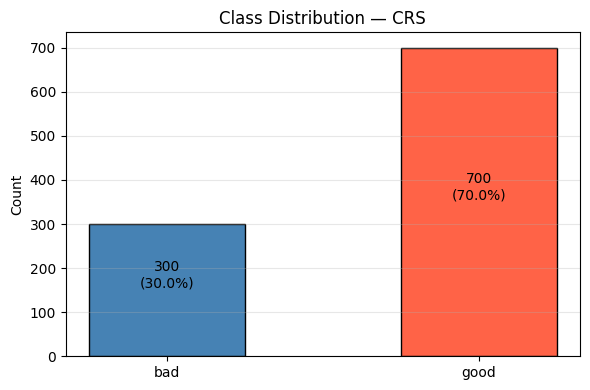


NOTE: The dataset has significant class imbalance (70% good vs 30% bad).
      We must use stratify=y in train_test_split and StratifiedKFold for CV
      to ensure each split preserves this ratio. Consider ROC-AUC over accuracy.


In [133]:
# Count and percentage per class
class_counts = pd.Series(y).value_counts().sort_index()
class_labels = ['bad', 'good']
total = len(y)

print("=== Class Distribution ===")
for cls, label in zip(['bad', 'good'], class_labels):
    n = class_counts.get(cls, 2)
    print(f"  {label:>6s} (class {cls}): {n:6d}  ({n/total*100:.1f}%)")
    #print(n)

imbalance_ratio = class_counts.get("bad", 0) / max(class_counts.get("good", 1), 1)
print(f"\nImbalance ratio (bad : good) = {imbalance_ratio:.2f} : 1")
print(f"\nIf a cost matrix wasn't already provided, we could use the inverse of this ratio as the cost of misclassification errors.")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['steelblue', 'tomato']
bars = ax.bar(class_labels,
              [class_counts.get("bad", 0), class_counts.get("good", 0)],
              color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Count')
ax.set_title('Class Distribution — CRS')
ax.grid(True, alpha=0.3, axis='y')
for bar, cls in zip(bars, ['bad', 'good']):
    n = class_counts.get(cls, 2)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height()-(bar.get_height()/2),
            f"{n}\n({n/total*100:.1f}%)",
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print()
print("NOTE: The dataset has significant class imbalance (70% good vs 30% bad).")
print("      We must use stratify=y in train_test_split and StratifiedKFold for CV")
print("      to ensure each split preserves this ratio. Consider ROC-AUC over accuracy.")

### Numerical Feature Distributions & Outlier Detection

In [134]:
numeric = ['duration',
 'amount',
 'age']

categorical = ['status',
 'credit_history',
 'purpose',
 'savings',
 'employment_duration',
 'installment_rate',
 'personal_status_sex',
 'other_debtors',
 'present_residence',
 'property',
 'other_installment_plans',
 'housing',
 'number_credits',
 'job',
 'people_liable',
 'telephone',
 'foreign_worker']

Since there is only 1000 samples we will not touch the outliers, except analyzing them below:

=== IQR-Based Outlier Analysis ===

  Q2 (median) is displayed as a red line.
  IQR = Q3 - Q1  (width of the middle 50% of values)
  Fence: Lower = Q1 - 1.5*IQR,  Upper = Q3 + 1.5*IQR
  Any point outside [Lower, Upper] is flagged as an outlier.

Feature                    Q1       Q2       Q3      IQR      Lower      Upper   Outliers    Pct
----------------------------------------------------------------------------------------------------
duration                 12.0     18.0     24.0     12.0       -6.0       42.0         70   7.0%
amount                 1365.5   2319.5   3972.2   2606.8    -2544.6     7882.4         72   7.2%
age                      27.0     33.0     42.0     15.0        4.5       64.5         23   2.3%


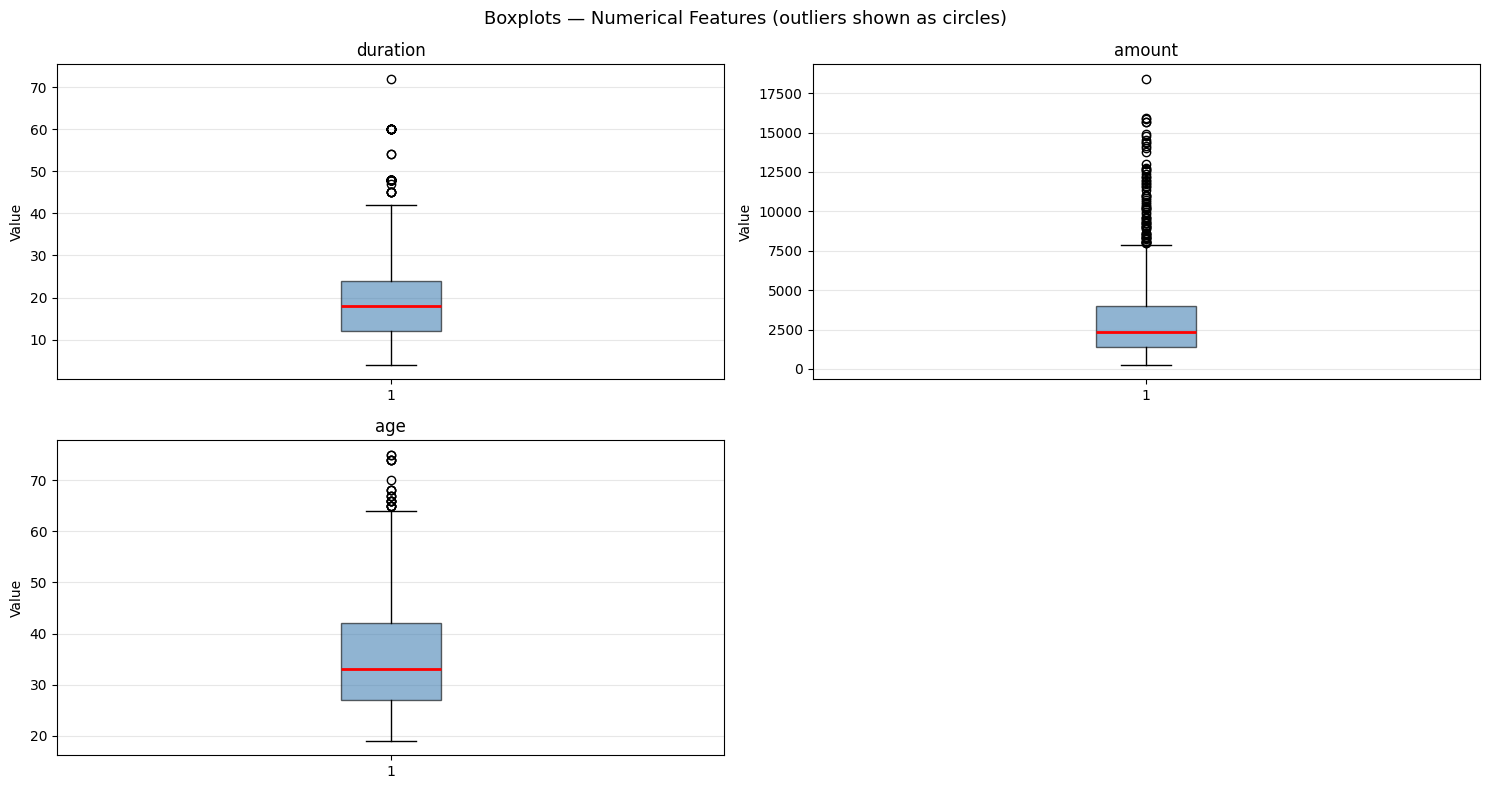

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()

print("Since there is only 1000 samples we will not touch the outliers, except analyzing them below:")
print()
print("=== IQR-Based Outlier Analysis ===")
print()
print("  Q2 (median) is displayed as a red line.")
print("  IQR = Q3 - Q1  (width of the middle 50% of values)")
print("  Fence: Lower = Q1 - 1.5*IQR,  Upper = Q3 + 1.5*IQR")
print("  Any point outside [Lower, Upper] is flagged as an outlier.")
print()
print(f"{'Feature':<20} {'Q1':>8} {'Q2':>8} {'Q3':>8} {'IQR':>8} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'Pct':>6}")
print("-" * 100)

for i, feat in enumerate(numeric):
    col_data = df[feat].dropna() 

    Q1  = col_data.quantile(0.25)
    Q2  = col_data.quantile(0.5) #median
    Q3  = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((col_data < lower) | (col_data > upper)).sum()
    pct   = n_out / len(col_data) * 100

    print(f"{feat:<20} {Q1:>8.1f} {Q2:>8} {Q3:>8.1f} {IQR:>8.1f} {lower:>10.1f} {upper:>10.1f} {n_out:>10d} {pct:>5.1f}%")

    ax = axes[i]
    ax.boxplot(col_data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat)
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_visible(False)

plt.suptitle('Boxplots — Numerical Features (outliers shown as circles)', fontsize=13)
plt.tight_layout()
plt.show()


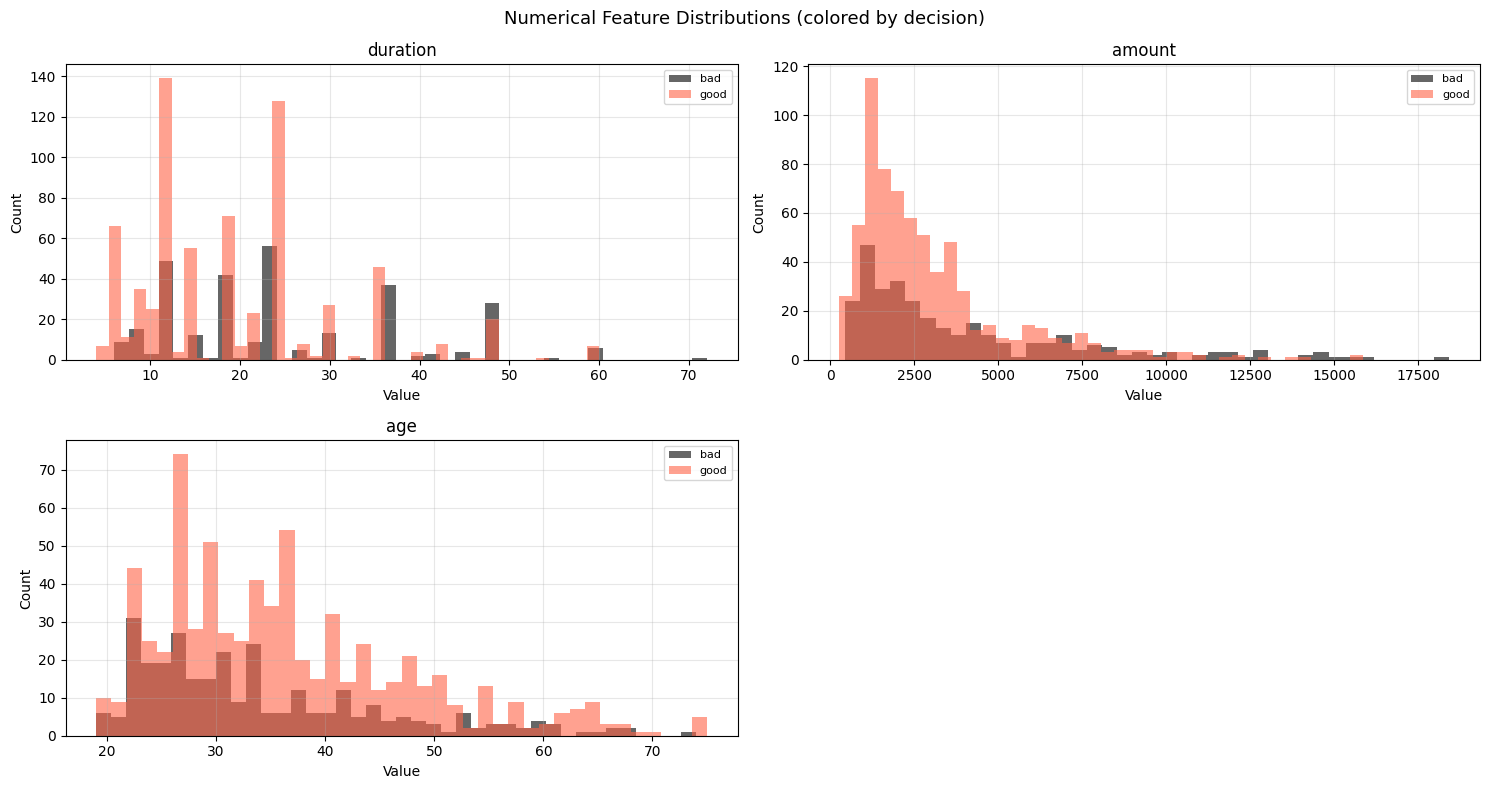

Key observations:
  duraton — roughly uniform, discrete
  amount  — right-skewed; weighting factor, wide range
  age - approximately normal, slight right skew; most bad loaners in (20-40) range


In [136]:
num_features = numeric
# Add target to a combined dataframe for coloring
df_plot = df[num_features].copy()
df_plot['credit_risk'] = df['credit_risk']

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()

color_map = {0: 'black', 1: 'tomato'}
label_map = {0: 'bad', 1: 'good'}

for i, feat in enumerate(num_features):
    ax = axes[i]
    for cls in [0, 1]:
        subset = df_plot[df_plot['credit_risk'] == cls][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color_map[cls],
                label=label_map[cls], edgecolor='none')
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions (colored by decision)', fontsize=13)
plt.tight_layout()
plt.show()


print("Key observations:")
print("  duraton — roughly uniform, discrete")
print("  amount  — right-skewed; weighting factor, wide range")
print("  age - approximately normal, slight right skew; most bad loaners in (20-40) range")

### Categorical Feature Analysis

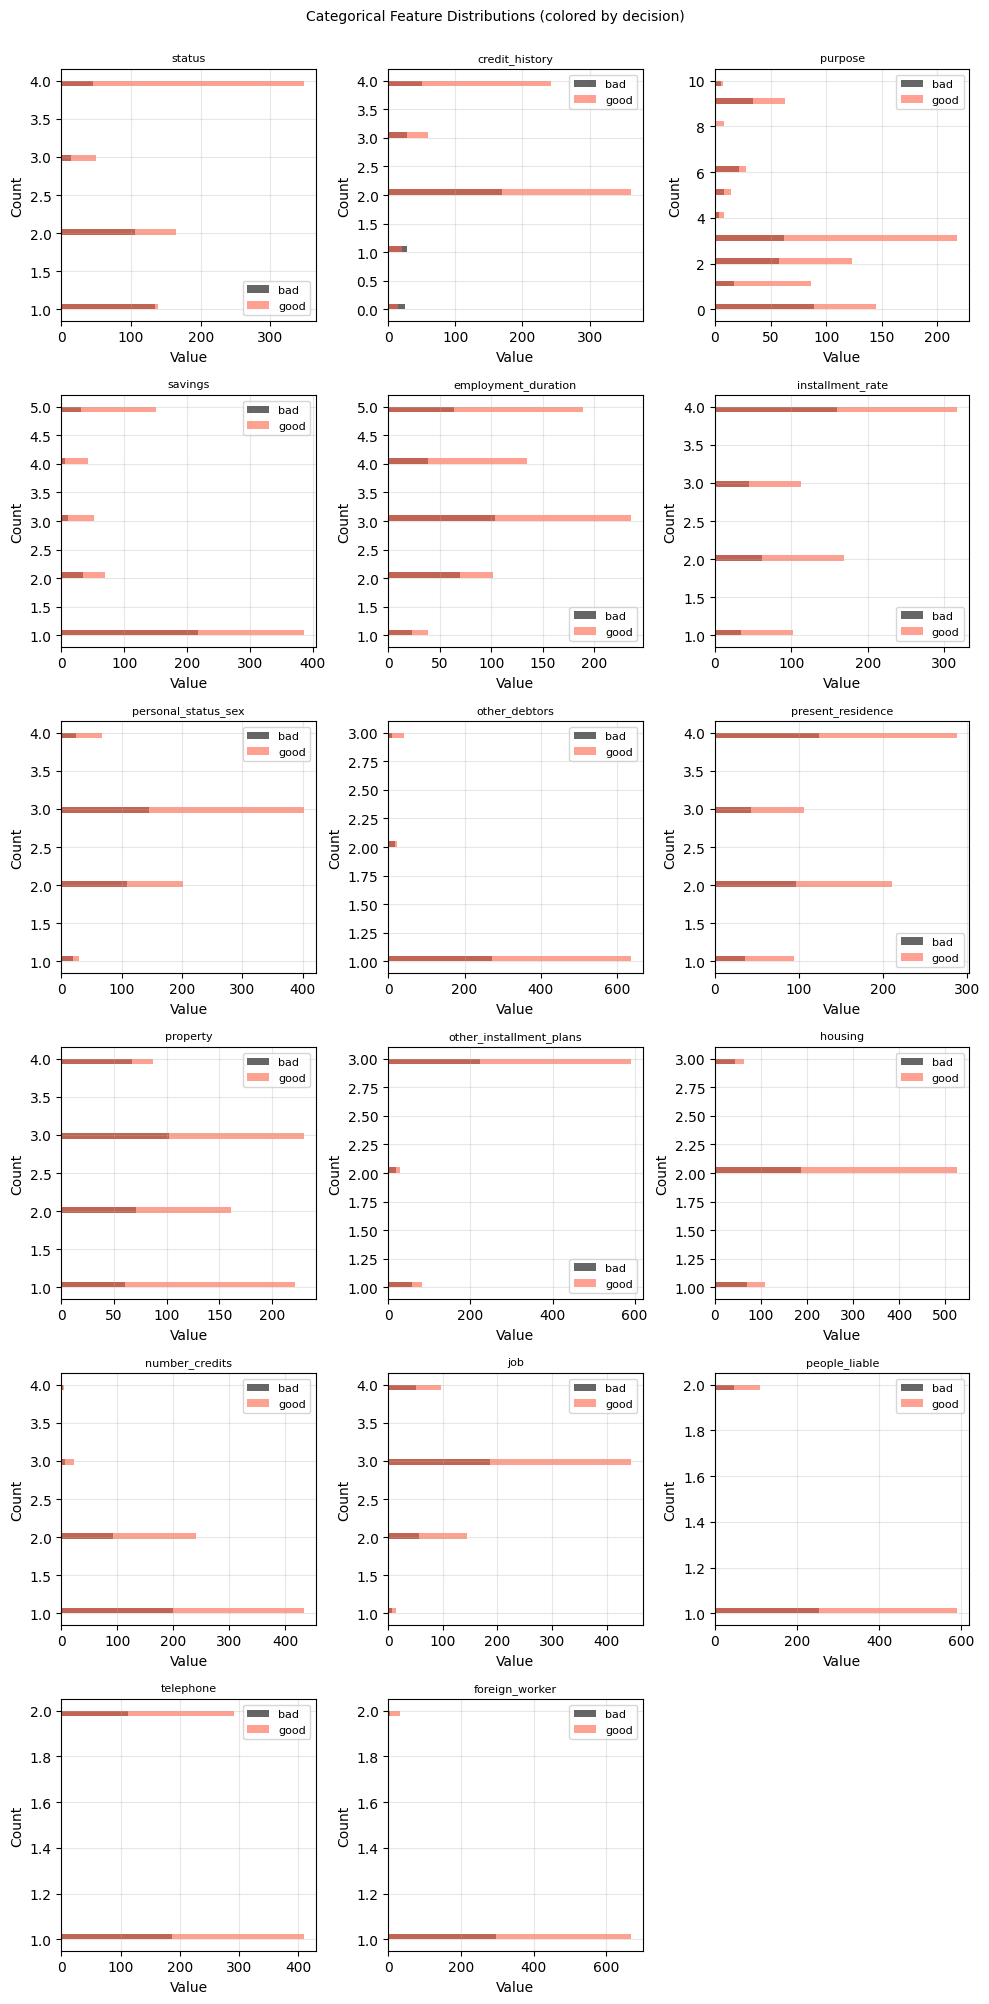

Key observations:
  status  — the more money they have in checking, the more favorable the odds towards a good score
  credit_history  — biggest risk in 'no credits taken/all credits paid back duly' category
  purpose  — biggest bad loans in 'others' category 
  savings  — the most have no (disclosed) savings, and this category is also the most risky
  employment_duration  — mainly uniform distribution
  installment_rate  — biggest category is 'rate < 20 of disposable income', good/bad outcomes almost evenly split for it
  personal_status_sex  — category 'male : married/widowed' loans the most
  other_debtors  — almost everyone has no co-applicant/guarantor
  present_residence  — majority are stable housed
  property  — biggest ratio of bad loans is with the real estate owners 
  other_installment_plans  — most have no other loans
  housing  — vast majority of the clients lives under rent
  number_credits  — the more credits the client has historically had, the better the odds of payin

In [137]:
cat_features = categorical

# We only plot the top 10 categories per feature to keep charts readable
df_cat_plot = df[cat_features].copy()
df_cat_plot['credit_risk'] = df['credit_risk']

fig, axes = plt.subplots(6, 3, figsize=(10, 20))
axes = axes.flatten()

color_map = {0: 'black', 1: 'tomato'}
label_map = {0: "bad", 1: "good"}

for i, feat in enumerate(cat_features):
    ax = axes[i]
    for cls in [0, 1]:
        subset = df_cat_plot[df_cat_plot['credit_risk'] == cls][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color_map[cls],
                label=label_map[cls], edgecolor='none',orientation='horizontal')
    ax.set_title(feat,fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the last subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Feature Distributions (colored by decision)', fontsize=10,y=1)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  status  — the more money they have in checking, the more favorable the odds towards a good score")
print("  credit_history  — biggest risk in 'no credits taken/all credits paid back duly' category")
print("  purpose  — biggest bad loans in 'others' category ")
print("  savings  — the most have no (disclosed) savings, and this category is also the most risky")
print("  employment_duration  — mainly uniform distribution")
print("  installment_rate  — biggest category is 'rate < 20 of disposable income', good/bad outcomes almost evenly split for it")
print("  personal_status_sex  — category 'male : married/widowed' loans the most")
print("  other_debtors  — almost everyone has no co-applicant/guarantor")
print("  present_residence  — majority are stable housed")
print("  property  — biggest ratio of bad loans is with the real estate owners ")
print("  other_installment_plans  — most have no other loans")
print("  housing  — vast majority of the clients lives under rent")
print("  number_credits  — the more credits the client has historically had, the better the odds of paying the new one off")
print("  job  — the majority are skilled")
print("  people_liable  — majority liable for 0-2 people, good/bad outcomes almost evenly split among them")
print("  telephone  — landline (since the data is collected in the 70s)")
print("  foreign_worker  — most workers are domestic, good/bad outcomes almost evenly split among them")

### Default rate across notable features

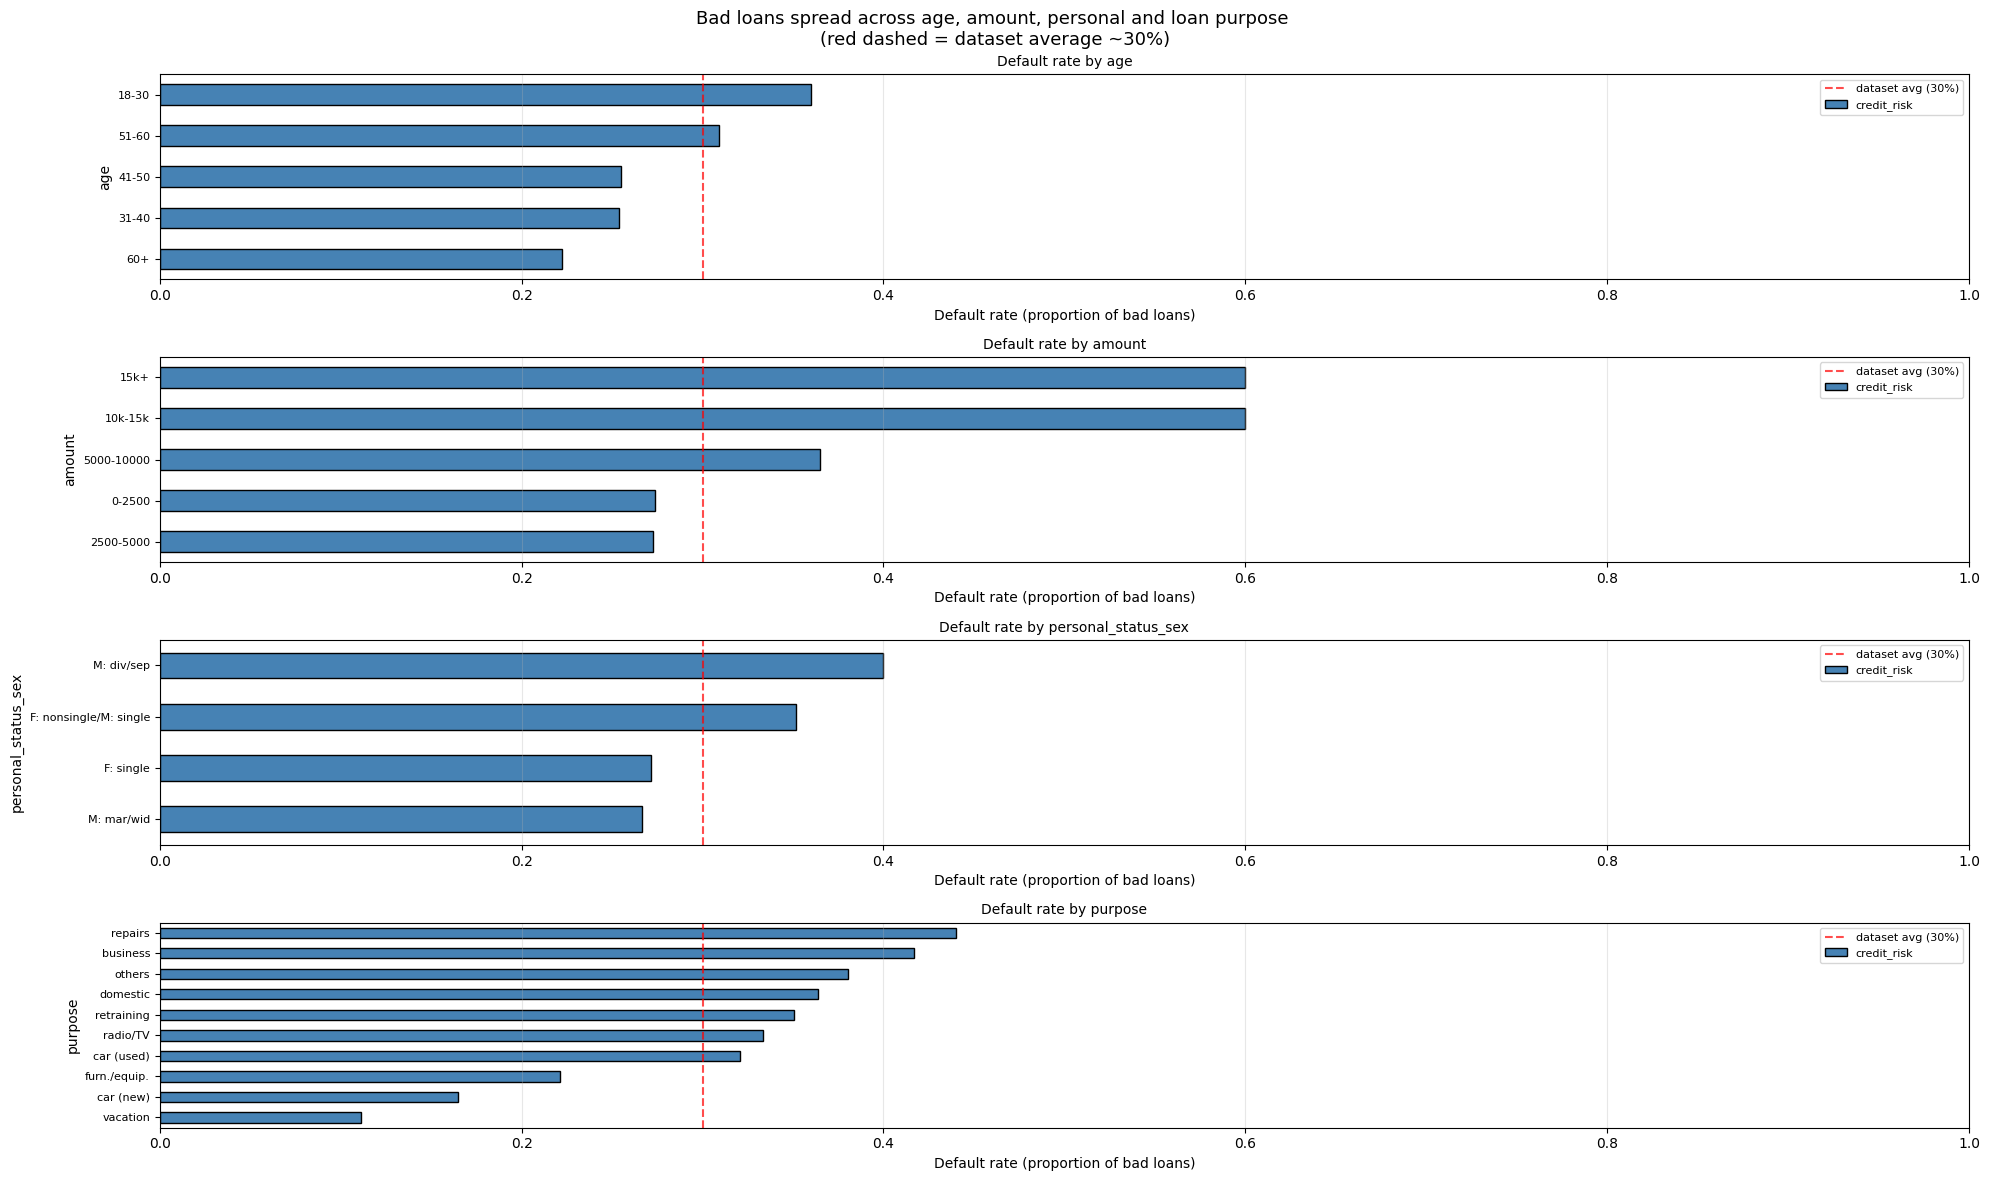

In [138]:
age_bins   = [18, 30, 40, 50, 60, 100]
age_labels = ['18-30', '31-40', '41-50', '51-60', '60+']

amount_bins   = [0, 2500, 5000, 10000, 15000,20000]
amount_labels = ['0-2500', '2500-5000', '5000-10000', '10k-15k', '15k+']

personal_status_sex_map = {
    1: 'M: div/sep',
    2: 'F: nonsingle/M: single',
    3: 'M: mar/wid',
    4: 'F: single'
}
 
purpose_map = {
    0:'others',  1:'car (new)', 2:'car (used)',
    3:'furn./equip.',   4:'radio/TV', 5:'domestic',
    6:'repairs',  7:'education',   8:'vacation',
    9:'retraining',   10:'business'
}
 
df_rate = df.copy()
df_rate['age']      = pd.cut(df['age'], bins=age_bins, labels=age_labels)
df_rate['amount']      = pd.cut(df['amount'], bins=amount_bins, labels=amount_labels)
df_rate['personal_status_sex'] = df['personal_status_sex'].map(personal_status_sex_map)
df_rate['purpose']  = df['purpose'].map(purpose_map)
 
features = ['age','amount','personal_status_sex','purpose']
fig, axes = plt.subplots(4,1, figsize=(20, 12))
axes = axes.flatten()

#Target is 0=bad/default, 1=good, so .mean() gives "good rate"; use (1 - mean) for "default rate"
dataset_default_rate = 1 - df['credit_risk'].mean()  # fraction of bad loans
 
for i, feat in enumerate(features):
    ax = axes[i]
    # 1 - mean() converts "good rate" -> "default rate"
    rate = (1 - df_rate.groupby(feat, observed=True)['credit_risk'].mean()).dropna().sort_values()
    rate.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Default rate by {feat}', fontsize=10)
    ax.set_xlabel('Default rate (proportion of bad loans)')
    ax.set_xlim(0, 1)
    ax.axvline(dataset_default_rate, color='red', linestyle='--', alpha=0.7,
               label=f'dataset avg ({dataset_default_rate:.0%})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Bad loans spread across age, amount, personal and loan purpose \n(red dashed = dataset average ~30%)', fontsize=13)
plt.tight_layout()
plt.show()

### Correlation analysis

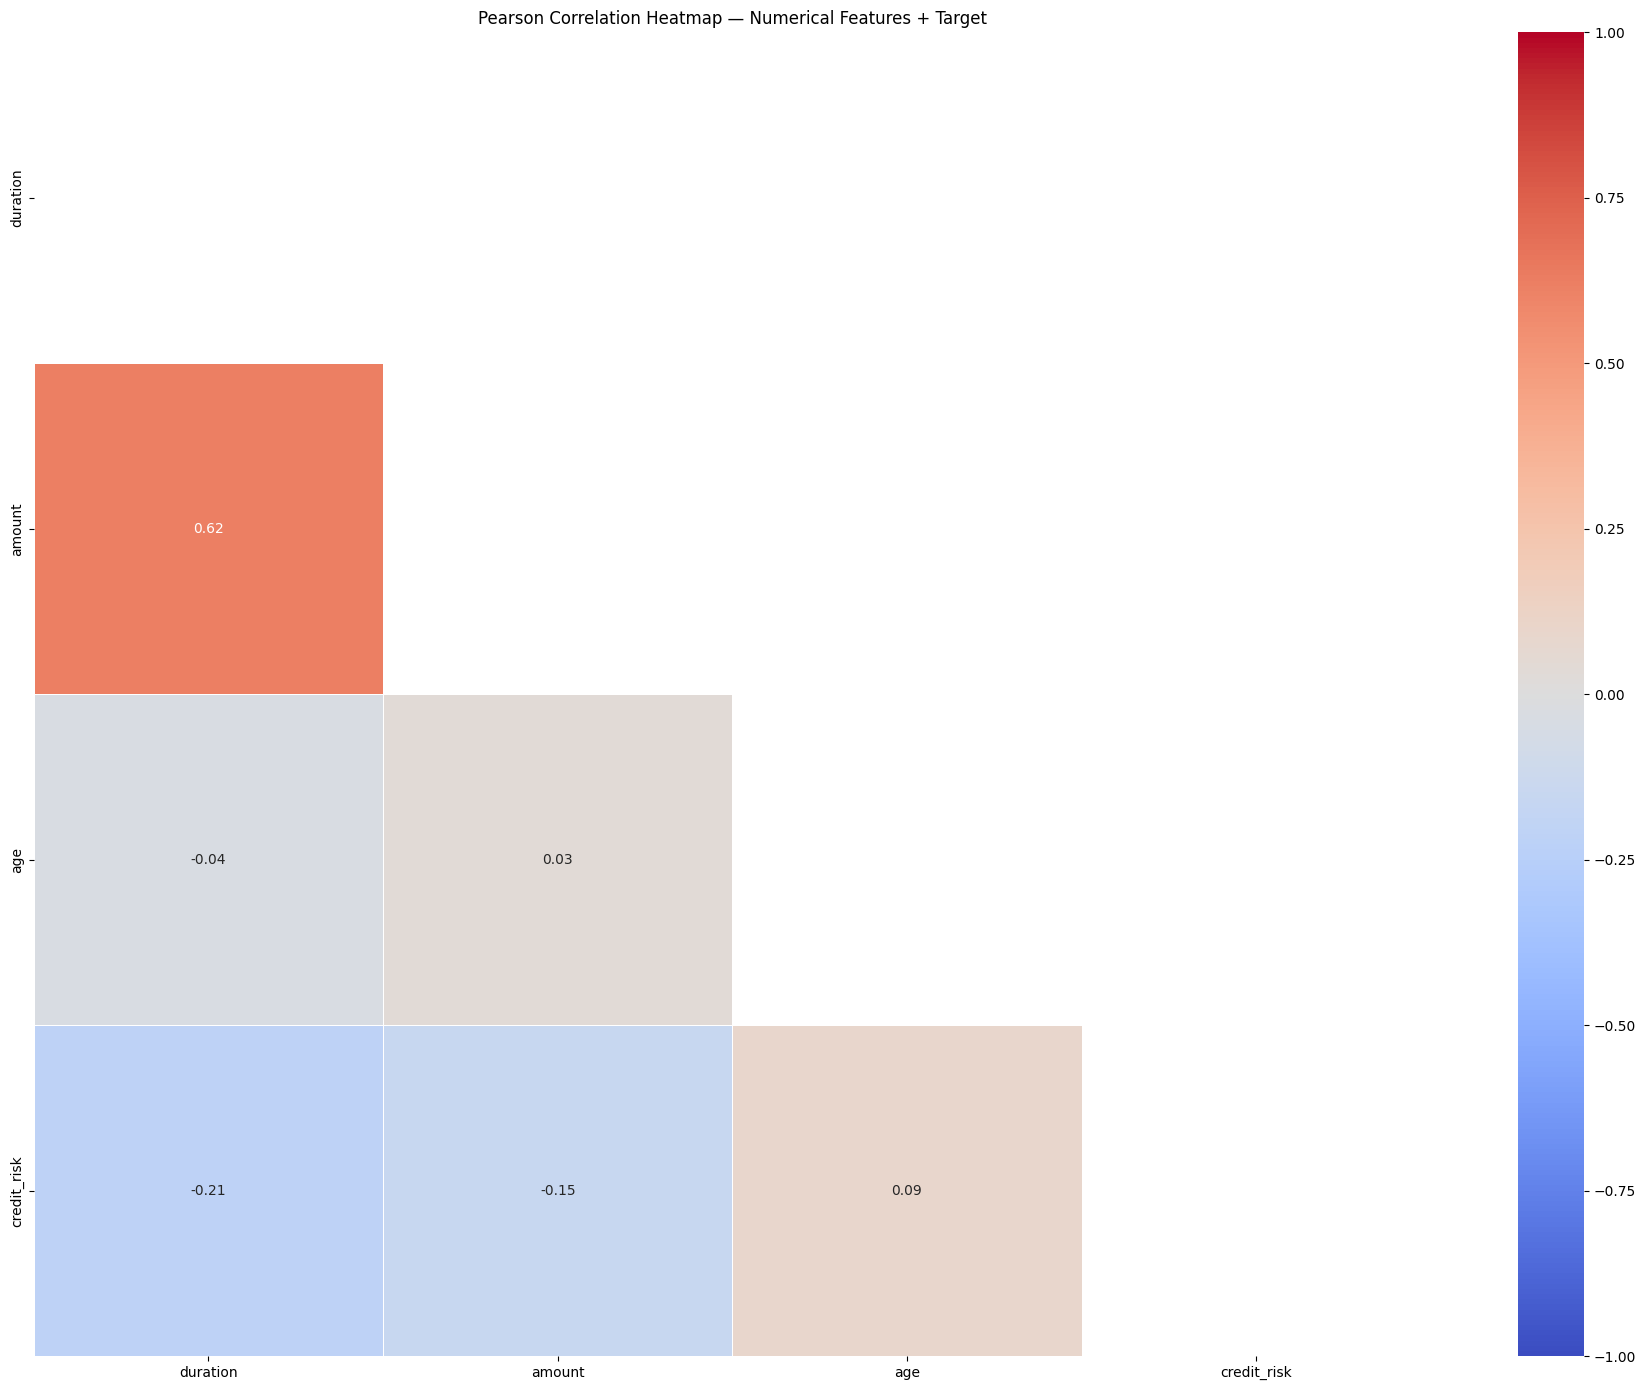

Correlations with credit_risk (|r|, descending):
  duration            : 0.215
  amount              : 0.155
  age                 : 0.091

Observations:
  duration has the strongest linear correlation with credit_risk (~0.21)
  duration and amount correlate heavily (0.62) - the bigger the credit, the longer you pay it off


In [139]:
# Correlation matrix for numerical features + target
df_corr = df[num_features].copy()
df_corr['credit_risk'] = df['credit_risk']

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    mask=mask
)
ax.set_title('Pearson Correlation Heatmap — Numerical Features + Target', fontsize=12)
plt.tight_layout()
plt.show()

# Print correlations with target sorted by absolute value
target_corr = corr_matrix['credit_risk'].drop('credit_risk').abs().sort_values(ascending=False)
print("Correlations with credit_risk (|r|, descending):")
for feat, val in target_corr.items():
    print(f"  {feat:<20}: {val:.3f}")

print()
print("Observations:")
print("  duration has the strongest linear correlation with credit_risk (~0.21)")
print("  duration and amount correlate heavily (0.62) - the bigger the credit, the longer you pay it off")

## Preprocessing Decisions (Discussion)

Based on the EDA, we will proceed as outlined below:

### Missing Values
There is none.

### Outliers 
**Decision**: Leave them as-is, 1000 is a small sample so best not to remove any values.

### Scaling
**Decision**: Yes, `StandardScaler` handles skew for numeric values.

### Categorical Encoding
**Decision**: Yes, `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` for categorical values, with the indicated parameters which achieve the following:

- Creates binary indicator columns for each category level
- Ignores any unseen categories at test time (prevents crashes)

### Feature Redundancy
 
**Decision**: Since we already start with a small number of features, for starters we will use them all to have a baseline measurement for the model. Further experiments with dropping bias features in section III.

### Feature Enrichment
 
**Decision**: Unfortunately impossible to cleanly split the personal_status_sex column into sex/status. No enrichment.

### Class Imbalance
~70% / 30% imbalance is moderate.

**Decision**: We will use `stratify=y` in train/test split for all the models and `StratifiedKFold` in CV for evaluating which models to select from the starting pool. Models will be evaluated with ROC-AUC (threshold-independent) in addition to accuracy. A next step would be `class_weight='balanced'` (covered in section III).

### [Extra]

**Enrichment**: Model the asymmetric cost of errors — approving a bad loan costs the bank far more 
than rejecting a good one. How does this change your optimal decision?

**Decision**: We will factor in the cost matrix in the calculations, both as a bias correction factor and in evaluation. In addition, we will provide a cost in DM so that we can see an approximate monetary value per loan for each model.

## II Modeling

### Feature Selection & Train/Test Split

In [140]:
numerical_cols   = numeric
categorical_cols = categorical

FEATURES = numerical_cols + categorical_cols
print("Selected features:", FEATURES)
print(f"  Numerical   ({len(numerical_cols)}): {numerical_cols}")
print(f"  Categorical ({len(categorical_cols)}): {categorical_cols}")
print()

X = df[FEATURES].copy()
y = df['credit_risk']

# Train / test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set shape:", X_train.shape)
print("Test  set shape:", X_test.shape)
print()
print("Train class distribution:")
vc_train = pd.Series(y_train).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_train.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_train)*100:.1f}%)")

print()
print("Test class distribution:")
vc_test = pd.Series(y_test).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_test.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_test)*100:.1f}%)")

Selected features: ['duration', 'amount', 'age', 'status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']
  Numerical   (3): ['duration', 'amount', 'age']
  Categorical (17): ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']

Train set shape: (800, 20)
Test  set shape: (200, 20)

Train class distribution:
  bad: 240 (30.0%)
  good: 560 (70.0%)

Test class distribution:
  bad: 60 (30.0%)
  good: 140 (70.0%)


### Build Preprocessing Pipeline

In [141]:
# Numerical sub-pipeline:
numerical_pipeline = Pipeline([
    ('scaler',  StandardScaler()),
])

# Categorical sub-pipeline: 
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer applies each sub-pipeline to the right columns
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,   numerical_cols),
    ('cat', categorical_pipeline, categorical_cols),
])

# Quick sanity check: fit on train, transform train
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("Processed train shape:", X_train_proc.shape)
print("Processed test shape:", X_test_proc.shape)
print()

# Extract feature names after preprocessing
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)
all_feature_names = numerical_cols + list(cat_feature_names)
print(f"Total features after OHE expansion: {len(all_feature_names)}")
print("\nFirst 20 feature names:")
print(all_feature_names[:20])

Processed train shape: (800, 71)
Processed test shape: (200, 71)

Total features after OHE expansion: 71

First 20 feature names:
['duration', 'amount', 'age', 'status_1', 'status_2', 'status_3', 'status_4', 'credit_history_0', 'credit_history_1', 'credit_history_2', 'credit_history_3', 'credit_history_4', 'purpose_0', 'purpose_1', 'purpose_2', 'purpose_3', 'purpose_4', 'purpose_5', 'purpose_6', 'purpose_8']


### Model Selection with Cross-Validation

In [142]:
def make_pipeline(clf):
    """Wrap a classifier with the shared preprocessor in a sklearn Pipeline."""
    return Pipeline([
        ('preprocessor', ColumnTransformer(transformers=[
            ('num', Pipeline([
                ('scaler',  StandardScaler()),
            ]), numerical_cols),
            ('cat', Pipeline([
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), categorical_cols),
        ])),
        ('clf', clf)
    ])


models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(max_iter=1000 
                           #random_state=42 - we will pass this manually in the pipeline where needed
                           )
    ),
    'Decision Tree': make_pipeline(
        DecisionTreeClassifier(max_depth=6, random_state=42)
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
    ),
    'SVM (RBF)': make_pipeline(
        SVC(C=1, gamma='scale', probability=True, random_state=42)
    ),
    'MLP (Neural Net)': make_pipeline(
        MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("Running 5-fold Stratified Cross-Validation on training set...")
print("Baseline Model Performance (BMP) taken from UCI (where available)")
print()
baseline = {"Logistic Regression":0.75,"Random Forest":0.78,"SVM (RBF)":0.70,"Decision Tree":0,'Xgboost Classification':0.74,
            'MLP (Neural Net)':0.64}
print(f"{'Model':<20}  {'Mean Acc':>5}  {'Std':>5} {'BMP':>7}")
print('-' * 50)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model':   name,
        'CV Mean': round(scores.mean(), 4),
        'CV Std':  round(scores.std(),  4),
        'CV Min':  round(scores.min(),  4),
        'CV Max':  round(scores.max(),  4),          
    })
    print(f"{name:<20}  {scores.mean():.4f}  ±{scores.std():.4f}  {baseline[name]:.4f}")

df_cv = pd.DataFrame(cv_results).sort_values('CV Mean', ascending=False)
print()
print("Ranked by CV Accuracy:")
print(df_cv.to_string(index=False))

Running 5-fold Stratified Cross-Validation on training set...
Baseline Model Performance (BMP) taken from UCI (where available)

Model                 Mean Acc    Std     BMP
--------------------------------------------------
Logistic Regression   0.7737  ±0.0584  0.7500
Decision Tree         0.6912  ±0.0252  0.0000
Random Forest         0.7525  ±0.0378  0.7800
SVM (RBF)             0.7625  ±0.0377  0.7000
MLP (Neural Net)      0.7475  ±0.0539  0.6400

Ranked by CV Accuracy:
              Model  CV Mean  CV Std  CV Min  CV Max
Logistic Regression   0.7737  0.0584  0.7250  0.8875
          SVM (RBF)   0.7625  0.0377  0.7062  0.8000
      Random Forest   0.7525  0.0378  0.7125  0.8188
   MLP (Neural Net)   0.7475  0.0539  0.7000  0.8500
      Decision Tree   0.6912  0.0252  0.6562  0.7312


### Hyperparameter Tuning

From the preliminary options and results above we will proceed with the following algorithms:

1. Starting with Random Forest or Logistic Regression as a baseline - RF works almost everywhere without scaling; LR tells you if the problem is linear.
2. If interpretability is required (healthcare, finance, legal): use Decision Tree (fully explainable) or Logistic Regression (coefficients).
3. Neural networks enhance risk assesment. Even though this dataset is small, we can use it to compare results with the other algorithms.

#### 1. Baseline (RF/LR comparison)

Already achieved in this exercise (rounded to 2 decimal spots):

| Model | CV Mean | CV Std | CV Min | CV Max |
| --- | --- | --- | --- | --- |
| Random Forest | 0.76 | 0.03 | 0.70 | 0.80 |
| Logistic Regression | 0.76 | 0.05 | 0.67 | 0.85 |

Baseline Model Performance (Accuracy) - from dataset
- Random Forest - 0.78
- Logistic Regression - 0.756

Baseline Model Performance (Precision) - from dataset
- Random Forest - 0.76179
- Logistic Regression - 0.71216

In [143]:
single = ['Random Forest', 'Logistic Regression']
for best_model_name in single:

    print(f"Best model from CV: {best_model_name}")
    print()

    # Build a fresh pipeline for tuning (avoid contamination from CV runs)
    if best_model_name == 'Random Forest':
        tuning_clf = RandomForestClassifier(n_jobs=-1, random_state=42)
        param_grid = {
            'clf__n_estimators':    [100, 200, 300],
            'clf__max_depth':       [None, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__criterion': ['gini','entropy','log_loss'],
            'clf__ccp_alpha': [0, 0.05, 0.1]
        }
    elif best_model_name == 'Logistic Regression':
        tuning_clf = LogisticRegression(random_state=42)
        param_grid = {
            'clf__C':        [0.01, 0.1, 1.0, 10.0],
            'clf__penalty':  ['l2'],
            'clf__solver':   ['liblinear','lbfgs'],
            'clf__max_iter':   [800,1000,1500]
        }
    else:
        # Generic fallback
        print("No model provided, try again")

    #add mode for missing models
    tuning_pipe = make_pipeline(tuning_clf)

    print(f"Param grid for {best_model_name}:")
    for k, v in param_grid.items():
        print(f"  {k}: {v}")
    total_combos = 1
    for v in param_grid.values():
        total_combos *= len(v)
    print(f"\nTotal combinations: {total_combos} x 5 folds = {total_combos * 5} fits")
    print("Running GridSearchCV (this may take a few minutes)...")
    start = time.time()

    grid_search = GridSearchCV(
        tuning_pipe,
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    print()
    print(f"Best parameters : {grid_search.best_params_}")
    print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")
    print(f"Time : {round(time.time() - start, 4):.4f} seconds")
    print("========================================")

Best model from CV: Random Forest

Param grid for Random Forest:
  clf__n_estimators: [100, 200, 300]
  clf__max_depth: [None, 5, 10]
  clf__min_samples_leaf: [1, 2, 4]
  clf__criterion: ['gini', 'entropy', 'log_loss']
  clf__ccp_alpha: [0, 0.05, 0.1]

Total combinations: 243 x 5 folds = 1215 fits
Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters : {'clf__ccp_alpha': 0, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 300}
Best CV ROC-AUC : 0.7983
Time : 116.9937 seconds
Best model from CV: Logistic Regression

Param grid for Logistic Regression:
  clf__C: [0.01, 0.1, 1.0, 10.0]
  clf__penalty: ['l2']
  clf__solver: ['liblinear', 'lbfgs']
  clf__max_iter: [800, 1000, 1500]

Total combinations: 24 x 5 folds = 120 fits
Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters : 

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


#### 2. Interpretability (DT/LR comparison)

Already achieved in this exercise (rounded to 2 decimal spots):

| Model | CV Mean | CV Std | CV Min | CV Max |
| --- | --- | --- | --- | --- |
| Decision Tree | 0.68 | 0.04 | 0.63 | 0.75 |
| Logistic Regression | 0.76 | 0.05 | 0.67 | 0.85 |

Baseline Model Performance (Accuracy) - from dataset
- Decision Tree - not measured
- Logistic Regression - 0.756

Baseline Model Performance (Precision) - from dataset
- Decision Tree - not measured
- Logistic Regression - 0.71216


In [144]:
single = ['Decision Tree', 'Logistic Regression']
for best_model_name in single:

    print(f"Best model from CV: {best_model_name}")
    print()

    # Build a fresh pipeline for tuning (avoid contamination from CV runs)
    if best_model_name == 'Decision Tree':
        tuning_clf = DecisionTreeClassifier(random_state=42)
        param_grid = {
            'clf__max_depth':        [4, 6, 8, 10],
            'clf__min_samples_split': [2, 10, 20],
            'clf__min_samples_leaf':  [1, 5, 10],
            'clf__criterion': ['gini','entropy','log_loss'],
            'clf__ccp_alpha': [0,0.05,0.1]
        }
    elif best_model_name == 'Logistic Regression':
        tuning_clf = LogisticRegression(random_state=42)
        param_grid = {
            'clf__C':        [0.01, 0.1, 1.0, 10.0],
            'clf__penalty':  ['l2'],
            'clf__solver':   ['liblinear','lbfgs'],
            'clf__max_iter':   [800,1000,1500]
        }
    else:
        # Generic fallback
        print("No model provided, try again")

    #add mode for missing models
    tuning_pipe = make_pipeline(tuning_clf)

    print(f"Param grid for {best_model_name}:")
    for k, v in param_grid.items():
        print(f"  {k}: {v}")
    total_combos = 1
    for v in param_grid.values():
        total_combos *= len(v)
    print(f"\nTotal combinations: {total_combos} x 5 folds = {total_combos * 5} fits")
    print("Running GridSearchCV (this may take a few minutes)...")
    start = time.time()
    
    grid_search = GridSearchCV(
        tuning_pipe,
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    print()
    print(f"Best parameters : {grid_search.best_params_}")
    print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")
    print(f"Time : {round(time.time() - start, 4):.4f} seconds")
    print("========================================")

Best model from CV: Decision Tree

Param grid for Decision Tree:
  clf__max_depth: [4, 6, 8, 10]
  clf__min_samples_split: [2, 10, 20]
  clf__min_samples_leaf: [1, 5, 10]
  clf__criterion: ['gini', 'entropy', 'log_loss']
  clf__ccp_alpha: [0, 0.05, 0.1]

Total combinations: 324 x 5 folds = 1620 fits
Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best parameters : {'clf__ccp_alpha': 0, 'clf__criterion': 'entropy', 'clf__max_depth': 6, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}
Best CV ROC-AUC : 0.7000
Time : 8.2583 seconds
Best model from CV: Logistic Regression

Param grid for Logistic Regression:
  clf__C: [0.01, 0.1, 1.0, 10.0]
  clf__penalty: ['l2']
  clf__solver: ['liblinear', 'lbfgs']
  clf__max_iter: [800, 1000, 1500]

Total combinations: 24 x 5 folds = 120 fits
Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters : 

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


#### 3. Neural Network

Already achieved in this exercise (rounded to 2 decimal spots):

| Model | CV Mean | CV Std | CV Min | CV Max |
| --- | --- | --- | --- | --- |
| MLP (Neural Net) | 0.73  | 0.05 | 0.66 | 0.83 |

Baseline Model Performance (Accuracy) - from dataset
- Neural Network Classification - 0.644

Baseline Model Performance (Precision) - from dataset
- Neural Network Classification - 0.59

In [145]:
single = ['MLP (Neural Net)']
for best_model_name in single:

    print(f"Best model from CV: {best_model_name}")
    print()

    # Build a fresh pipeline for tuning (avoid contamination from CV runs)
    if best_model_name == 'MLP (Neural Net)': 
        tuning_clf=MLPClassifier(random_state=42)
        param_grid = {
            'clf__max_iter': [300,500,800],
            'clf__hidden_layer_sizes':[(100,),(64,32)],
            'clf__activation': ['relu','tanh'],
            'clf__solver': ['adam','lbfgs','sgd']
        }
    else:
        # Generic fallback
        print("No model provided, try again")

    #add mode for missing models
    tuning_pipe = make_pipeline(tuning_clf)

    print(f"Param grid for {best_model_name}:")
    for k, v in param_grid.items():
        print(f"  {k}: {v}")
    total_combos = 1
    for v in param_grid.values():
        total_combos *= len(v)
    print(f"\nTotal combinations: {total_combos} x 5 folds = {total_combos * 5} fits")
    print("Running GridSearchCV (this may take a few minutes)...")
    start = time.time()

    grid_search = GridSearchCV(
        tuning_pipe,
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    print()
    print(f"Best parameters : {grid_search.best_params_}")
    print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")
    print(f"Time : {round(time.time() - start, 4):.4f} seconds")
    print("========================================")

Best model from CV: MLP (Neural Net)

Param grid for MLP (Neural Net):
  clf__max_iter: [300, 500, 800]
  clf__hidden_layer_sizes: [(100,), (64, 32)]
  clf__activation: ['relu', 'tanh']
  clf__solver: ['adam', 'lbfgs', 'sgd']

Total combinations: 36 x 5 folds = 180 fits
Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'clf__activation': 'relu', 'clf__hidden_layer_sizes': (100,), 'clf__max_iter': 800, 'clf__solver': 'sgd'}
Best CV ROC-AUC : 0.7977
Time : 39.9020 seconds


#### Building/comparing all the models with best parameters

In [146]:
lr= make_pipeline(
    LogisticRegression(random_state=42, max_iter=800, C=0.1,penalty='l2',solver='lbfgs'))
#Best parameters : {'clf__C': 0.1, 'clf__max_iter': 800, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

dt = make_pipeline(
    DecisionTreeClassifier(random_state=42,max_depth=4,min_samples_leaf=5,min_samples_split=2,criterion='entropy'))
#Best parameters : {'clf__ccp_alpha': 0, 'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}

rf = make_pipeline(
    RandomForestClassifier(random_state=42,criterion='entropy', max_depth=10, n_estimators=200,min_samples_leaf=1))
#Best parameters : {'clf__ccp_alpha': 0, 'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}

nn = make_pipeline(
    MLPClassifier(random_state=42,activation='tanh',hidden_layer_sizes=(100,),max_iter=800,solver='sgd'))
#Best parameters : {'clf__activation': 'tanh', 'clf__hidden_layer_sizes': (100,), 'clf__max_iter': 800, 'clf__solver': 'sgd'}

Cost matrix


In [147]:
# # cost_matrix rows = actual class (0=bad, 1=good), cols = predicted class (0=bad, 1=good):
# # adjusted to fit confusion matrix - multiply overlapping fields and sum
# #   [0][0]=0  TN: bad correctly rejected
# #   [0][1]=5  FP: bad wrongly approved   <- bank loses money, biggest cost!
# #   [1][0]=1  FN: good wrongly rejected  <- bank doesn't lose money on the loan, but lost a good customer in the long run
# #   [1][1]=0  TP: good correctly approved

cost_matrix = [
    [0,5],
    [1,0]
]

average_loan = df['amount'].mean()
#picked over median because it is a slightly bigger value

# "approve nobody"    -> all 700 good customers wrongly rejected (cost 1 each)
costs_nobody = (700 * cost_matrix[1][0] + 300 * cost_matrix[0][0]) / 1000 #700 FN, 300 TN = 0.7

# "approve everybody" -> all 300 bad customers wrongly approved (cost 5 each)
costs_everybody = (700 * cost_matrix[1][1] + 300 * cost_matrix[0][1]) / 1000 #700TP , 300 FP = 1.5

# A good model cost (on test set of 200) should be lower than the naive "approve everybody" scaled to test size:
naive_best_on_test = costs_everybody * len(y_test)
naive_best_DM = costs_everybody * average_loan

print(f"Our goal is to minimize the costs, and thereby maximize the expected profit.")
print()
print(f"Naive baseline - approve nobody     avg cost per loan: {costs_nobody:.2f}")
print(f"Naive baseline - approve everybody  avg cost per loan: {costs_everybody:.2f}")
print()
print(f"Target: model total cost on test set < {naive_best_on_test:.0f}")
print(f"Target: model total cost - naive baseline (in DM) < {naive_best_DM:.0f}")

Our goal is to minimize the costs, and thereby maximize the expected profit.

Naive baseline - approve nobody     avg cost per loan: 0.70
Naive baseline - approve everybody  avg cost per loan: 1.50

Target: model total cost on test set < 300
Target: model total cost - naive baseline (in DM) < 4907


In [148]:
final_results = pd.DataFrame(columns=['Model','CV Accuracy','ROC-AUC', 'CV F1 (good)','Train time','Cost (naive 300)','Cost in DM (naive 4907)'])
cm_results = pd.DataFrame(columns=['Model','TN','FP (cost 5)', 'FN (cost 1)','TP'])

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


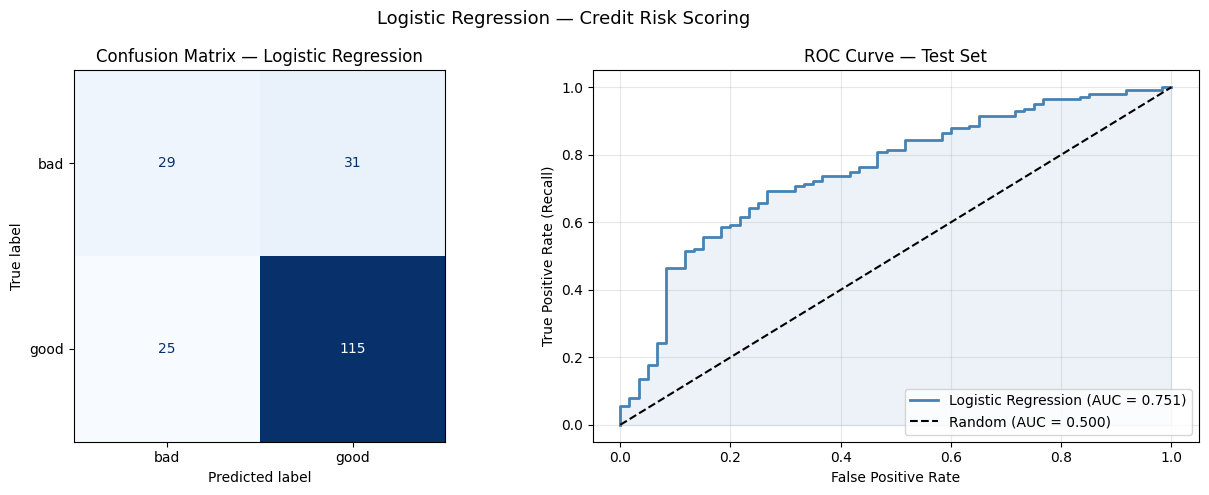

=== Logistic Regression ===
Accuracy: 0.72
ROC-AUC: 0.7512
Cost: 180
Cost in DM: 2944

              precision    recall  f1-score   support

         bad       0.54      0.48      0.51        60
        good       0.79      0.82      0.80       140

    accuracy                           0.72       200
   macro avg       0.66      0.65      0.66       200
weighted avg       0.71      0.72      0.72       200



In [149]:
# Logistic regression
best_pipeline=lr

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Logistic Regression')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — Credit Risk Scoring', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Logistic Regression ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

final_results.loc[len(final_results)] = ['Logistic Regression',acc,test_auc,f1,train_time,cost,costDM]
cm_results.loc[len(cm_results)] = ['Logistic Regression',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

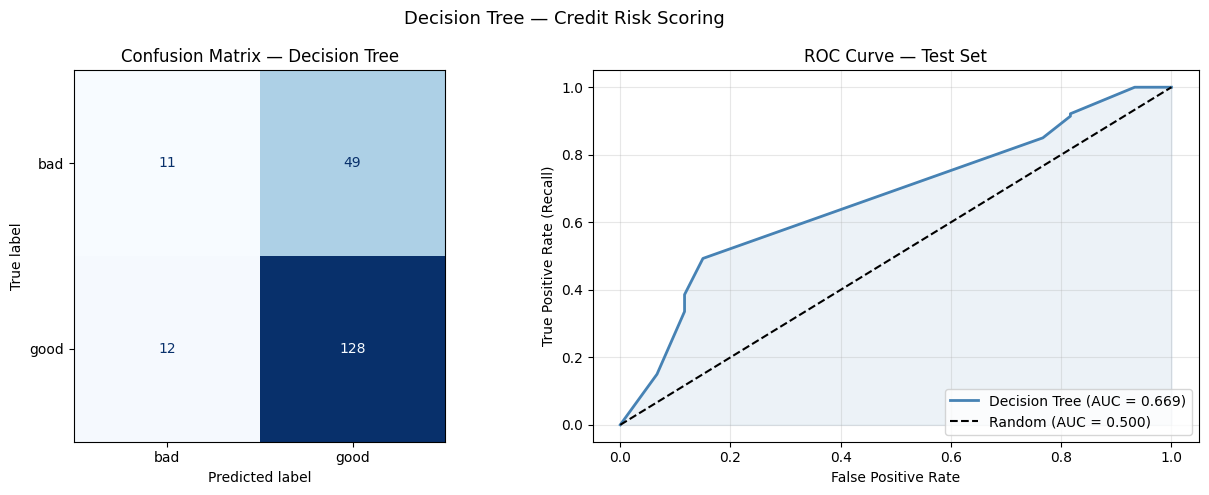

=== Decision Tree ===
Accuracy: 0.695
ROC-AUC: 0.6687
Cost: 257
Cost in DM: 4203

              precision    recall  f1-score   support

         bad       0.48      0.18      0.27        60
        good       0.72      0.91      0.81       140

    accuracy                           0.69       200
   macro avg       0.60      0.55      0.54       200
weighted avg       0.65      0.69      0.64       200



In [150]:
# Decision tree

best_pipeline=dt

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Decision Tree')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Decision Tree (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decision Tree — Credit Risk Scoring', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size


acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Decision Tree ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

final_results.loc[len(final_results)] = ['Decision Tree',acc,test_auc,f1,train_time,cost,costDM]
cm_results.loc[len(cm_results)] = ['Decision Tree',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

|--- cat__status_4 <= 0.50
|   |--- num__duration <= -0.77
|   |   |--- cat__installment_rate_2 <= 0.50
|   |   |   |--- cat__property_1 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__property_1 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- cat__installment_rate_2 >  0.50
|   |   |   |--- class: 1
|   |--- num__duration >  -0.77
|   |   |--- num__duration <= 2.20
|   |   |   |--- num__amount <= -0.65
|   |   |   |   |--- class: 0
|   |   |   |--- num__amount >  -0.65
|   |   |   |   |--- class: 1
|   |   |--- num__duration >  2.20
|   |   |   |--- cat__savings_5 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__savings_5 >  0.50
|   |   |   |   |--- class: 1
|--- cat__status_4 >  0.50
|   |--- cat__other_installment_plans_3 <= 0.50
|   |   |--- num__age <= 0.80
|   |   |   |--- cat__present_residence_1 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__present_residence_1 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- num__age >  0.80
|   |   | 

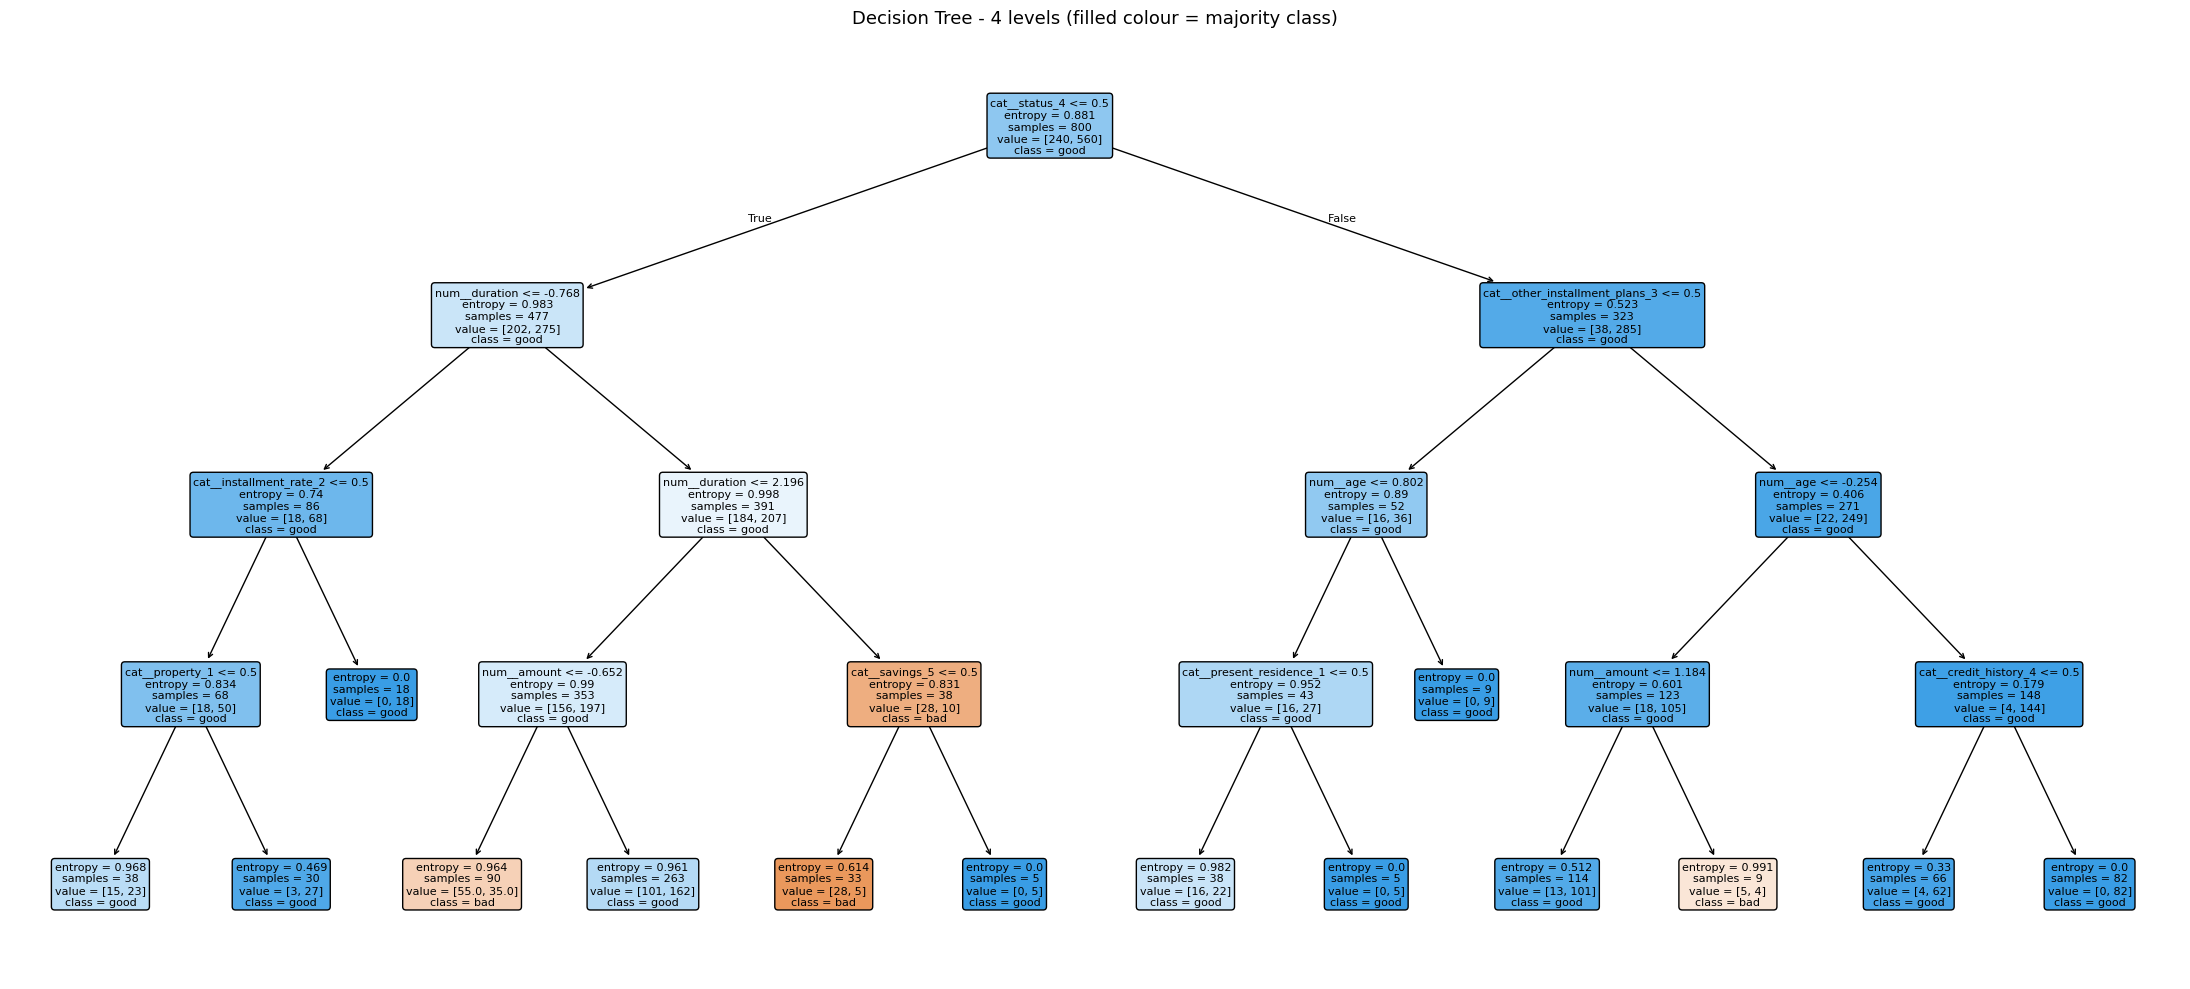

In [151]:
# FIX [Issue: "how to visualize tree from pipeline"]
# Problem: plot_tree() needs the raw DecisionTreeClassifier, not the Pipeline object.
# Solution: extract the classifier with  dt.named_steps['clf']
#           and get feature names with   dt.named_steps['preprocessor'].get_feature_names_out()
 
dt_clf = dt.named_steps['clf']
feature_names_out = list(dt.named_steps['preprocessor'].get_feature_names_out())
 
# Text representation (compact, good for inspection)
print(export_text(dt_clf, feature_names=feature_names_out, max_depth=4))
 
# Visual tree
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_clf,
    feature_names=feature_names_out,
    class_names=['bad', 'good'],
    max_depth=4,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.title('Decision Tree - 4 levels (filled colour = majority class)', fontsize=13)
plt.tight_layout()
plt.show()

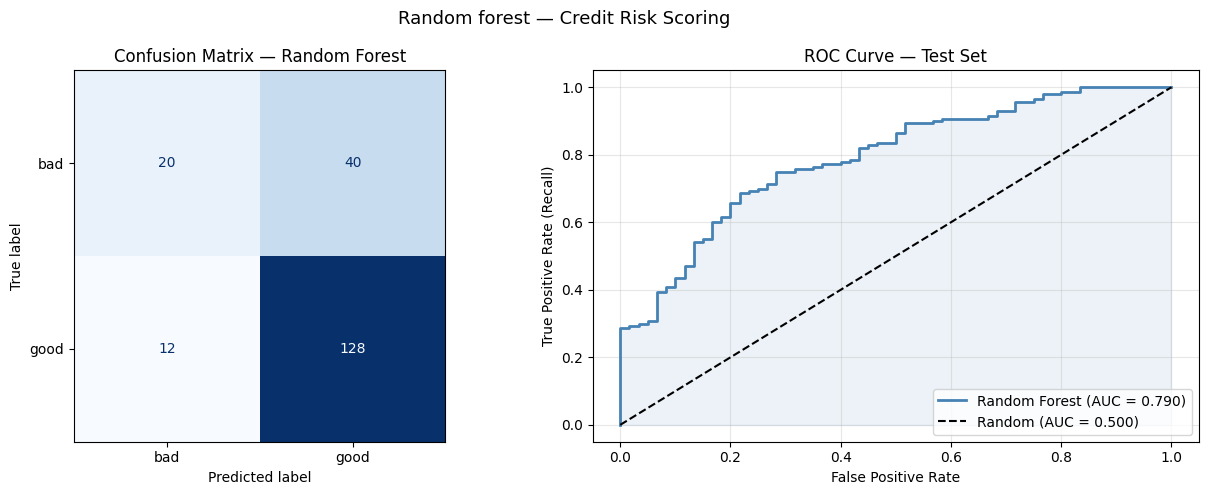

=== Random Forest ===
Accuracy: 0.74
ROC-AUC: 0.7902
Cost: 212
Cost in DM: 3467

              precision    recall  f1-score   support

         bad       0.62      0.33      0.43        60
        good       0.76      0.91      0.83       140

    accuracy                           0.74       200
   macro avg       0.69      0.62      0.63       200
weighted avg       0.72      0.74      0.71       200



In [152]:
# Random forest
best_pipeline=rf

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)


# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Random Forest')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Random Forest (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Random forest — Credit Risk Scoring', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Random Forest ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

final_results.loc[len(final_results)] = ['Random Forest',acc,test_auc,f1,train_time,cost,costDM]
cm_results.loc[len(cm_results)] = ['Random Forest',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

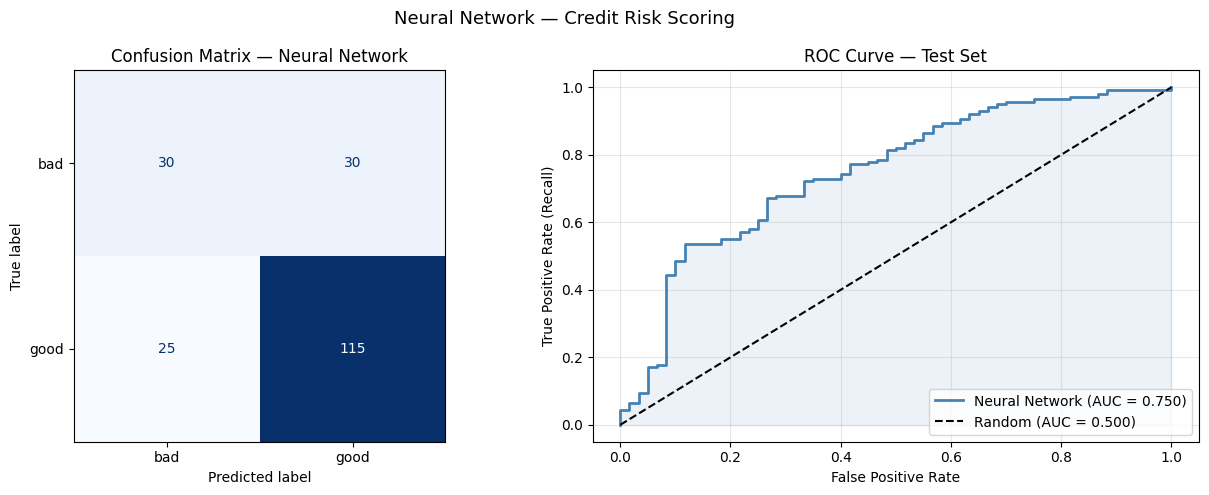

=== Neural Network ===
Accuracy: 0.725
ROC-AUC: 0.7502
Cost: 175
Cost in DM: 2862

              precision    recall  f1-score   support

         bad       0.55      0.50      0.52        60
        good       0.79      0.82      0.81       140

    accuracy                           0.72       200
   macro avg       0.67      0.66      0.66       200
weighted avg       0.72      0.72      0.72       200



In [153]:
# Neural Network
best_pipeline=nn

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Neural Network')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Neural Network (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network — Credit Risk Scoring', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Neural Network ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

final_results.loc[len(final_results)] = ['Neural Network',acc,test_auc,f1,train_time,cost,costDM]
cm_results.loc[len(final_results)] = ['Neural Network',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

## Model results (Discussion)

In [154]:
print(final_results.to_string(index=False))

              Model  CV Accuracy  ROC-AUC  CV F1 (good)  Train time  Cost (naive 300)  Cost in DM (naive 4907)
Logistic Regression        0.720 0.751190      0.804196      0.0394               180                     2944
      Decision Tree        0.695 0.668690      0.807571      0.0343               257                     4203
      Random Forest        0.740 0.790238      0.831169      0.5256               212                     3467
     Neural Network        0.725 0.750238      0.807018      2.9100               175                     2862


In [155]:
###############
# # TN | FP # #
# # ------- # #
# # FN | TP # #
###############

print(cm_results.to_string(index=False))

              Model  TN  FP (cost 5)  FN (cost 1)  TP
Logistic Regression  29           31           25 115
      Decision Tree  11           49           12 128
      Random Forest  20           40           12 128
     Neural Network  30           30           25 115


We can see from the results above that all our models outperform the naive costs we calculated with the provided cost matrix . In addition, similar results were achieved compared to the expected ones provided with the data set.
The neural network is similar result-wise with Logistic Regression (which is the industry standard), except for the train time which is significantly costlier. If we consider the fact that the data is tabular and the dataset itself is quite simple (not a lot of rows and features), it's overkill to use it in such cases when the traditional models give the same results at a much lower cost.

Due to its simplicity and its smallest cost per loan, in the next section we will use *Logistic Regression* and compare how the modifications affect the results.

## III Research Direction - Algorithmic fairness in credit scoring

Machine learning models are not inherently objective - they are simply tools that process and discover links in the data they are provided.
As such, this makes them succeptible to bias, as the quality of the results of the model can only match the level of data it is provided.
It's important to be aware of common human biases that can manifest in the data, so that we can take steps to correct or remediate their effects.

A few definitions that we could consider for our case:

 - *Historical bias* occurs when historical data reflects inequities that existed in the world at that time. 
 As the data is closely tied to the place and time it is collected in, in our case Germany in the time period between 1973 to 1975, we will compare some statistics from the dataset to the demographic data found [here](https://ourworldindata.org/profile/population-demography/germany)

    Some examples:
  
    Median age in:
    - our dataset: 33
    - Germany in 1973-1975: 33.7-34.0-34.4

    Total dependency ratio in (% of working-age population):
    - our dataset: cannot be measured as values are grouped (for the dependants); but if we consider age as a category, we have 23 clients above 64 and 0 below 15, so for our dataset the percentage would be 97.7%
    - Germany in 1973-1975: 58%-57.6%-57%
  
    From these two examples we can see that sometimes the historical data is directly reflected in the dataset, and sometimes some values are overinflated due to nonrepresentative sampling (we can't have accurate demographic data in a lending dataset as kids don't have bank accounts). For example, woman's rights were not the same in the past, in regards to being able to work, have a fair salary or a bank account. If we use old data (like in our case) without considering the biases of the era from which the data originated, we could on accident reinstate the same old biases in modern times.

 - *Automation bias* is a tendency to favor results generated by automated systems over those generated by non-automated systems, irrespective of the error rates of each.
 This is important when we discuss the choices of a certain model over another, because the use case must match the specific needs of the industry. In sensitive areas (ex. healthcare) it's always better to pick explainable results with worse accuracy/precision than a 'black box' model. Logistic regression is often considered the gold standard for binary classification tasks because it is simple, interpretable, and effective at predicting probabilities for categorical outcomes, and as such I have chosen it as a baseline for my bias research.

 - *Sampling bias* occurs if proper randomization is not used during data collection.

   To avoid this, we used stratify=y in train_test_split and StratifiedKFold for CV to ensure each split preserves this ratio. ROC-AUC was also included in the final results.

- *Confirmation bias* occurs when model builders unconsciously process data in ways that affirm pre-existing beliefs and hypotheses.

   or similarly

- *Experimenter's bias* occurs when a model builder keeps training a model until it produces a result that aligns with their original hypothesis.

   We must not fit or cherry-pick the results to our hypothesis, but the other way around.

And finally we have ageism, sexism and the other prejudices that are discriminatory against a specific group because of their age, gender, ethnicity or race. **We must make sure that the model does not favor or disfavor a client based on these parameters.**

From the [Credit Scoring Approaches Guidelines](https://thedocs.worldbank.org/en/doc/935891585869698451-0130022020/original/CREDITSCORINGAPPROACHESGUIDELINESFINALWEB.pdf) , cited below:

The ECOA of 1974, which is implemented by the FRB’s Regulation B, applies to all CSPs. The statute requires financial institutions and other firms engaged in the extension of credit to **“make credit equally available to all creditworthy
customers without regard to sex or marital status.”**

With regard to credit transactions, a creditor cannot discriminate on the basis of the following:

- An applicant’s race, marital status, nationality, gender, age, or religion
- An applicant whose income is derived from a public assistance program
- An applicant who, in good faith, exercised their rights under the Consumer Credit Protection Act


Bias enters at different stages in the machine learning modeling pipeline, which we categorize
into three broad stages in which we may impose fairness: pre-training, in-processing, and
post-training. We will attempt all three approaches and compare to the baseline results we already achieved.

I. Pre-training - remove the features that cause bias (in our case age and personal_status_sex) and retrain. 

We have already covered proper sampling (stratify=y) and normalization in the base model, in addition to data revision according to the guidelines provided in South German Credit. There was no need for further cleanup/imputing as the records contained no nulls or duplicates.

II. In-processing - use the costs as a penalty for misclassification when the algorithms are trained. 

Given that most machine learning algorithms are trained to minimize error, cost for misclassification is added to the error or used to weigh the error during the training process.  In our case since we have chosen to work with Logistic Regression, this will be achieved with the class_weight argument.

III. Post-training - there are several methods in which this can be achieved, but in the interest of keeping the exercise simple, we will only attempt randomization. 

Randomization is one of the simplest and most effective (but worst-performing) methods of debiasing an algorithm. The premise of this is to reduce the accuracy on the majority group to equalize performance with the minority group. If a skin cancer detection algorithm has a 90% accuracy on the majority group and an 80% accuracy on the minority group, the simplest fix would be to randomize with some probability whenever the majority group is encountered. For example, if the majority class is the X variable, randomize the assigned class 20% of the time.


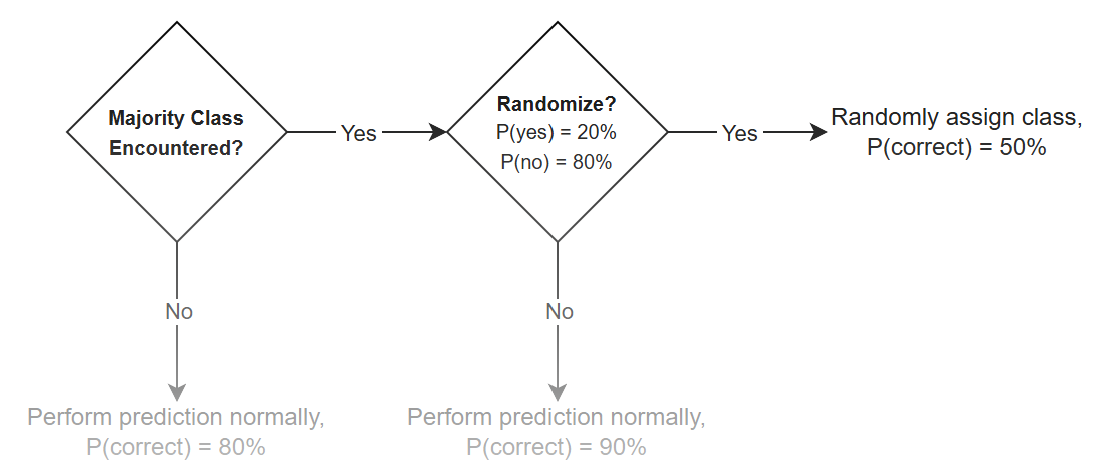

[source](https://www.educative.io/courses/mitigating-disasters-in-ml-pipelines/post-training-model-bias-mitigation)

### I - Pre-training

#### Feature Selection & Train/Test Split

In [156]:
#directly omitting the biased columns

numeric_bias = ['duration',
 'amount']

categorical_bias = ['status',
 'credit_history',
 'purpose',
 'savings',
 'employment_duration',
 'installment_rate',
 'other_debtors',
 'present_residence',
 'property',
 'other_installment_plans',
 'housing',
 'number_credits',
 'job',
 'people_liable',
 'telephone',
 'foreign_worker']

In [157]:
numerical_cols   = numeric_bias
categorical_cols = categorical_bias

FEATURES = numerical_cols + categorical_cols
print("Selected features:", FEATURES)
print(f"  Numerical   ({len(numerical_cols)}): {numerical_cols}")
print(f"  Categorical ({len(categorical_cols)}): {categorical_cols}")
print()

X = df[FEATURES].copy()
y = df['credit_risk']

# Train / test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set shape:", X_train.shape)
print("Test  set shape:", X_test.shape)
print()
print("Train class distribution:")
vc_train = pd.Series(y_train).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_train.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_train)*100:.1f}%)")

print()
print("Test class distribution:")
vc_test = pd.Series(y_test).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_test.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_test)*100:.1f}%)")

Selected features: ['duration', 'amount', 'status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']
  Numerical   (2): ['duration', 'amount']
  Categorical (16): ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']

Train set shape: (800, 18)
Test  set shape: (200, 18)

Train class distribution:
  bad: 240 (30.0%)
  good: 560 (70.0%)

Test class distribution:
  bad: 60 (30.0%)
  good: 140 (70.0%)


#### Build Preprocessing Pipeline
No neeed to modify this part, we can build the model directly.

In [158]:
biased_results = pd.DataFrame(columns=['Model','CV Accuracy','ROC-AUC', 'CV F1 (good)','Train time','Cost (naive 300)','Cost in DM (naive 4907)'])
biased_results = final_results[final_results['Model'] == "Logistic Regression"]
biased_results.at[0,'Model'] = "LR - baseline"

biased_cm_results = pd.DataFrame(columns=['Model','TN','FP (cost 5)', 'FN (cost 1)','TP'])
biased_cm_results = cm_results[cm_results['Model'] == "Logistic Regression"]
biased_cm_results.at[0,'Model'] = "LR - baseline"

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


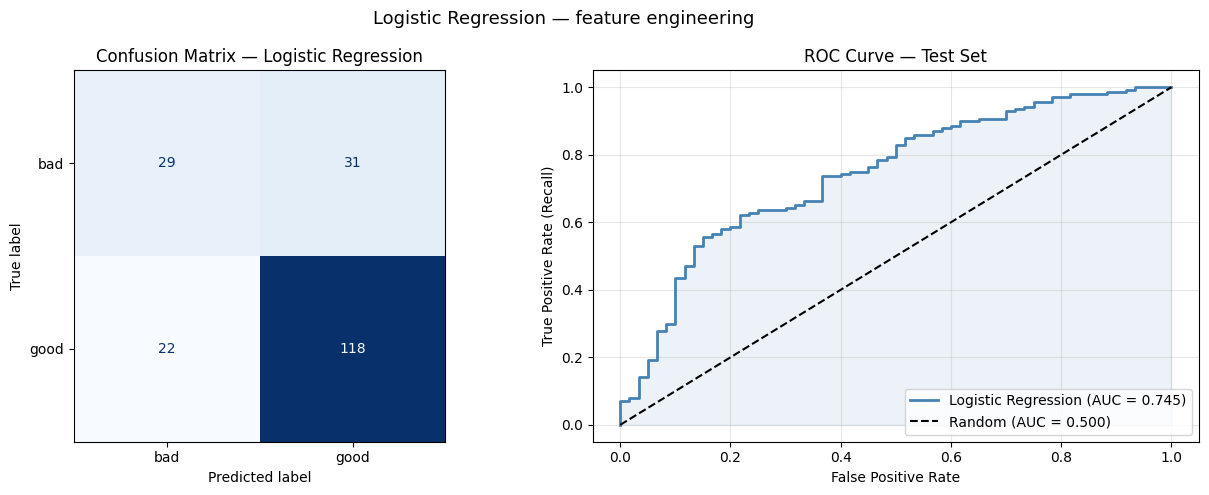

=== Logistic Regression - feature engineering ===
Accuracy: 0.735
ROC-AUC: 0.7452
Cost: 177
Cost in DM: 2895

              precision    recall  f1-score   support

         bad       0.57      0.48      0.52        60
        good       0.79      0.84      0.82       140

    accuracy                           0.73       200
   macro avg       0.68      0.66      0.67       200
weighted avg       0.72      0.73      0.73       200



In [159]:
lr= make_pipeline(
    LogisticRegression(random_state=42, max_iter=800, C=0.1,penalty='l2',solver='lbfgs'))

# Logistic regression
best_pipeline=lr

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Logistic Regression')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — feature engineering', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Logistic Regression - feature engineering ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

biased_results.loc[len(biased_results)] = ['LR - feature engineering',acc,test_auc,f1,train_time,cost,costDM]
biased_cm_results.loc[len(biased_cm_results)] = ['LR - feature engineering',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

### II - In training

#### Reset the values back to baseline & validate

In [160]:
numerical_cols   = numeric
categorical_cols = categorical

FEATURES = numerical_cols + categorical_cols
print("Selected features:", FEATURES)
print(f"  Numerical   ({len(numerical_cols)}): {numerical_cols}")
print(f"  Categorical ({len(categorical_cols)}): {categorical_cols}")
print()

X = df[FEATURES].copy()
y = df['credit_risk']

# Train / test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set shape:", X_train.shape)
print("Test  set shape:", X_test.shape)
print()
print("Train class distribution:")
vc_train = pd.Series(y_train).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_train.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_train)*100:.1f}%)")

print()
print("Test class distribution:")
vc_test = pd.Series(y_test).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_test.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_test)*100:.1f}%)")

Selected features: ['duration', 'amount', 'age', 'status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']
  Numerical   (3): ['duration', 'amount', 'age']
  Categorical (17): ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']

Train set shape: (800, 20)
Test  set shape: (200, 20)

Train class distribution:
  bad: 240 (30.0%)
  good: 560 (70.0%)

Test class distribution:
  bad: 60 (30.0%)
  good: 140 (70.0%)


c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


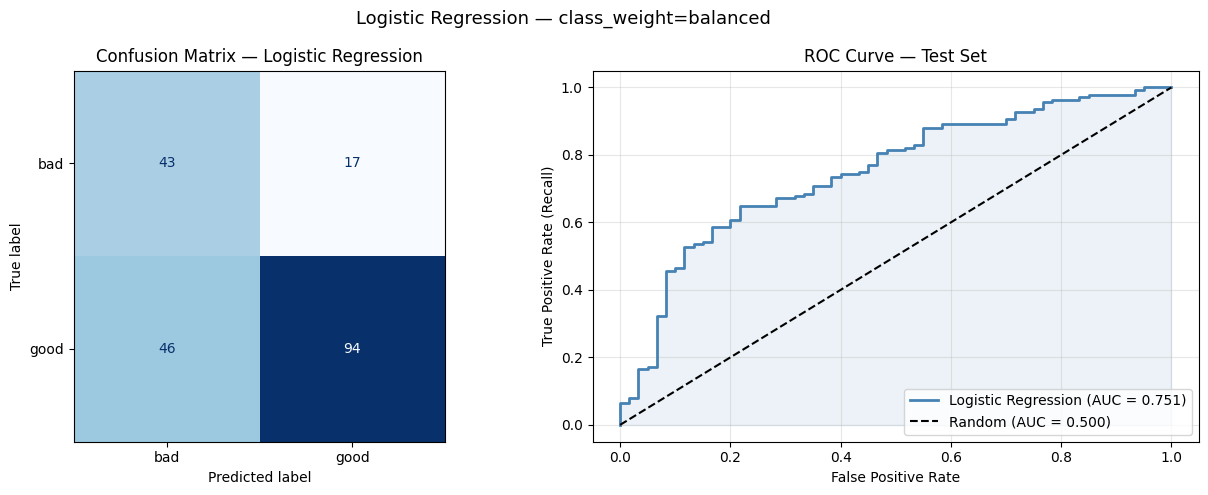

=== Logistic Regression - class_weight=balanced ===
Accuracy: 0.685
ROC-AUC: 0.7512
Cost: 131
Cost in DM: 2142

              precision    recall  f1-score   support

         bad       0.48      0.72      0.58        60
        good       0.85      0.67      0.75       140

    accuracy                           0.69       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.74      0.69      0.70       200



In [161]:
lr= make_pipeline(
    LogisticRegression(random_state=42, max_iter=800, C=0.1,penalty='l2',solver='lbfgs',class_weight='balanced'))

# Logistic regression
best_pipeline=lr

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Logistic Regression')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — class_weight=balanced', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Logistic Regression - class_weight=balanced ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

biased_results.loc[len(biased_results)] = ['LR - class_weight=balanced',acc,test_auc,f1,train_time,cost,costDM]
biased_cm_results.loc[len(biased_cm_results)] = ['LR - class_weight=balanced',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


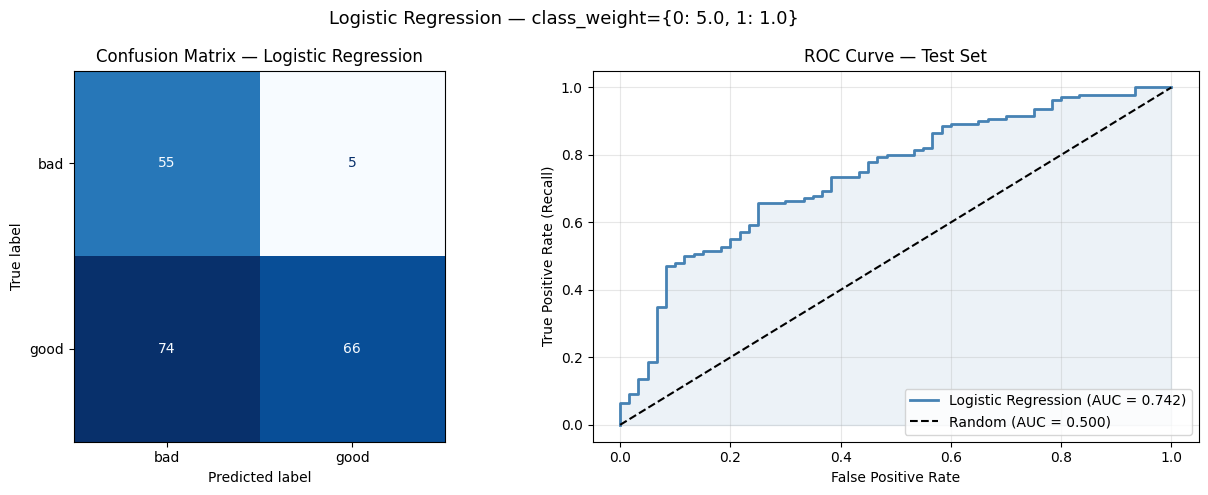

=== Logistic Regression — class_weight={0: 5.0, 1: 1.0} ===
Accuracy: 0.605
ROC-AUC: 0.7417
Cost: 99
Cost in DM: 1619

              precision    recall  f1-score   support

         bad       0.43      0.92      0.58        60
        good       0.93      0.47      0.63       140

    accuracy                           0.60       200
   macro avg       0.68      0.69      0.60       200
weighted avg       0.78      0.60      0.61       200



In [162]:
lr= make_pipeline(
    LogisticRegression(random_state=42, max_iter=800, C=0.1,penalty='l2',solver='lbfgs',class_weight={0: 5.0, 1: 1.0}))

# Logistic regression
best_pipeline=lr

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Logistic Regression')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — class_weight={0: 5.0, 1: 1.0}', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Logistic Regression — class_weight={0: 5.0, 1: 1.0} ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

biased_results.loc[len(biased_results)] = ['LR - class_weight={0: 5.0, 1: 1.0}',acc,test_auc,f1,train_time,cost,costDM]
biased_cm_results.loc[len(biased_cm_results)] = ['LR - class_weight={0: 5.0, 1: 1.0}',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


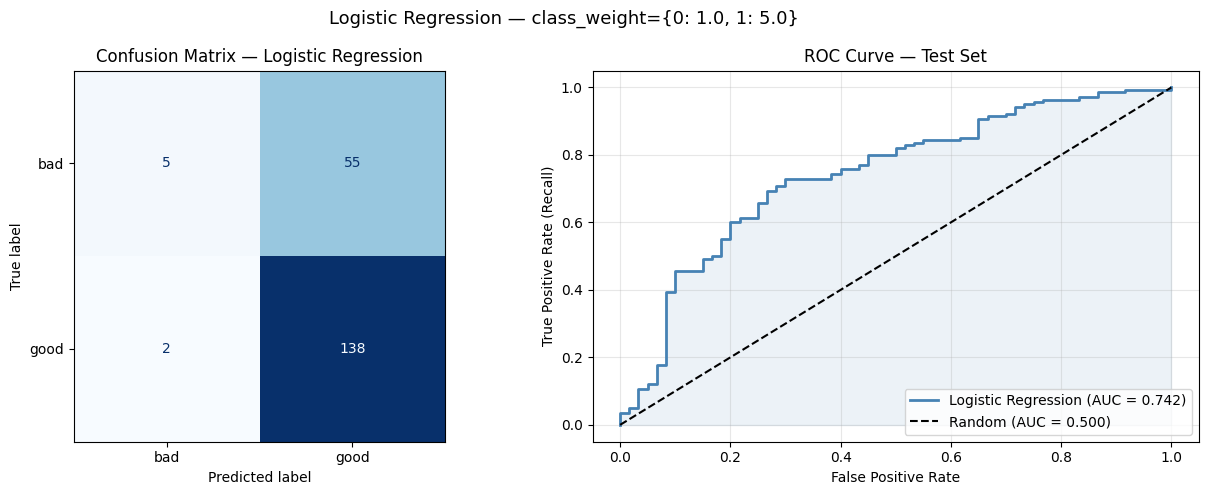

=== Logistic Regression - class_weight={0: 1.0, 1: 5.0} ===
Accuracy: 0.715
ROC-AUC: 0.7424
Cost: 277
Cost in DM: 4530

              precision    recall  f1-score   support

         bad       0.71      0.08      0.15        60
        good       0.72      0.99      0.83       140

    accuracy                           0.71       200
   macro avg       0.71      0.53      0.49       200
weighted avg       0.71      0.71      0.62       200



In [163]:
lr= make_pipeline(
    LogisticRegression(random_state=42, max_iter=800, C=0.1,penalty='l2',solver='lbfgs',class_weight={0: 1.0, 1: 5.0}))

# Logistic regression
best_pipeline=lr

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Logistic Regression')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — class_weight={0: 1.0, 1: 5.0}', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Logistic Regression - class_weight={0: 1.0, 1: 5.0} ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

biased_results.loc[len(biased_results)] = ['LR - class_weight={0: 1.0, 1: 5.0}',acc,test_auc,f1,train_time,cost,costDM]
biased_cm_results.loc[len(biased_cm_results)] = ['LR - class_weight={0: 1.0, 1: 5.0}',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

### III - Post-training

In [164]:
# Train / test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
    #random state removed for even more randomization
)

print("Train set shape:", X_train.shape)
print("Test  set shape:", X_test.shape)
print()
print("Train class distribution:")
vc_train = pd.Series(y_train).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_train.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_train)*100:.1f}%)")

print()
print("Test class distribution:")
vc_test = pd.Series(y_test).value_counts()
for cls, label in zip([0, 1], ['bad', 'good']):
    n = vc_test.get(cls, 0)
    print(f"  {label}: {n} ({n/len(y_test)*100:.1f}%)")

Train set shape: (800, 20)
Test  set shape: (200, 20)

Train class distribution:
  bad: 240 (30.0%)
  good: 560 (70.0%)

Test class distribution:
  bad: 60 (30.0%)
  good: 140 (70.0%)


In [165]:
lr= make_pipeline(
    LogisticRegression(max_iter=800, C=0.1,penalty='l2',solver='lbfgs'))
    #random state removed for even more randomization

# Logistic regression
best_pipeline=lr

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = round(time.time() - start, 4)

y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

##implementing randomization 
#20% of predicted 1s (majority) in y_pred
#aka calculate total 1s and then 20% of that number
#this will always be different for each run of the model

total_ones = np.count_nonzero(y_pred == 1)
print("Total 1s:", total_ones)
#round to a whole number
picks = int(total_ones * 0.2)
print("No. of values we will change:", picks)

#this is the amount of values we are changing
#in order to avoid changing the same field multiple times
#we will make an random array of len(picks) with positions of 1s in y_pred
pos = []
#and iterate through that
while(picks>0):
    i = random.randint(0, len(y_pred)-1)
    print("Trying for index",i)
    print("Value for this index is ",y_pred[i])
    if y_pred[i] == 1:
        pos.append(i)
        picks-=1
        print("Index added",i)
        continue
    if y_pred[i] == 0:
        #print("Predicted 0, try again")
        continue

#now that we have all the random indexes for i
print("Indexes of the values we are changing:")
print(pos)
len(pos)
for index in pos:
    #y_pred[i] - randomly assign 0/1
    new = random.randint(0, 1)
    print("Old value",y_pred[index])
    y_pred[index] = new
    print("New value",y_pred[index])
    #probability is the same for every value we iterate through
    y_proba[index] = 0.5
    #print("New probability",y_proba[index])
print("No. of changes made:",len(pos))
print("Done")

Total 1s: 149
No. of values we will change: 29
Trying for index 74
Value for this index is  1
Index added 74
Trying for index 198
Value for this index is  1
Index added 198
Trying for index 105
Value for this index is  1
Index added 105
Trying for index 186
Value for this index is  1
Index added 186
Trying for index 103
Value for this index is  1
Index added 103
Trying for index 40
Value for this index is  1
Index added 40
Trying for index 103
Value for this index is  1
Index added 103
Trying for index 170
Value for this index is  1
Index added 170
Trying for index 141
Value for this index is  1
Index added 141
Trying for index 32
Value for this index is  1
Index added 32
Trying for index 165
Value for this index is  0
Trying for index 157
Value for this index is  1
Index added 157
Trying for index 141
Value for this index is  1
Index added 141
Trying for index 147
Value for this index is  0
Trying for index 184
Value for this index is  1
Index added 184
Trying for index 100
Value for 

c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


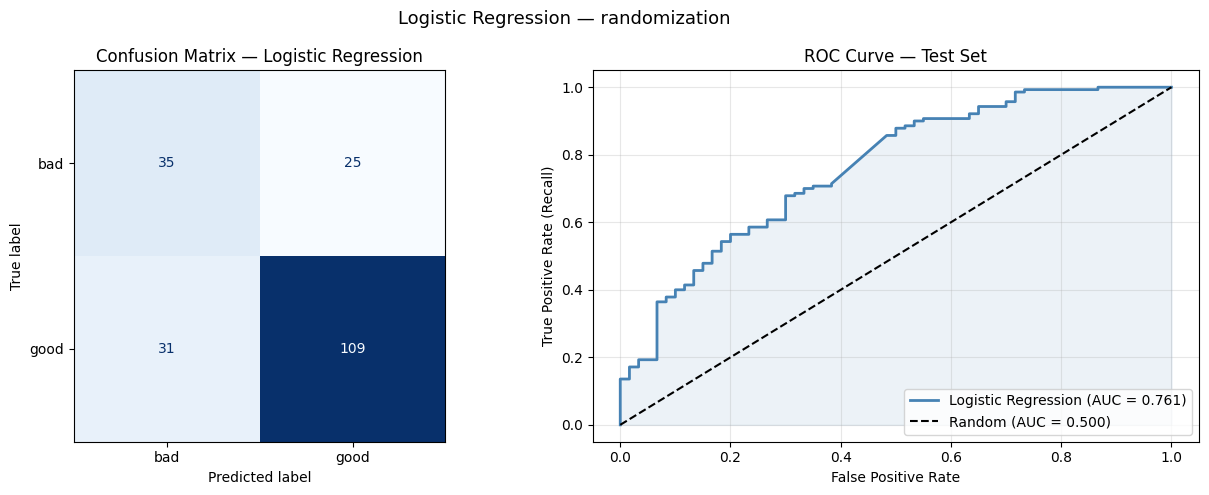

=== Logistic Regression - randomization ===
Accuracy: 0.72
ROC-AUC: 0.7607
Cost: 156
Cost in DM: 2551

              precision    recall  f1-score   support

         bad       0.53      0.58      0.56        60
        good       0.81      0.78      0.80       140

    accuracy                           0.72       200
   macro avg       0.67      0.68      0.68       200
weighted avg       0.73      0.72      0.72       200



In [166]:
test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

# Side-by-side: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['bad', 'good']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix — Logistic Regression')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba,pos_label=None)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — randomization', fontsize=13)
plt.tight_layout()
plt.show()

cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
#false positives and false negatives multiplied by average loan
costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

print("=== Logistic Regression - randomization ===")
print("Accuracy:", acc)
print(f"ROC-AUC: {test_auc:.4f}")
print("Cost:", cost)
print("Cost in DM:", costDM)
print()
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

biased_results.loc[len(biased_results)] = ['LR - randomization',acc,test_auc,f1,train_time,cost,costDM]
biased_cm_results.loc[len(biased_cm_results)] = ['LR - randomization',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]

In [167]:
randomtries = random.randint(2, 5)
print(f"Running {randomtries} more random attempts")

Running 2 more random attempts


The cell below will be executed a few more times, which will yield in multiple randomized results in addition to the one we just completed. An average of these results will be calculated and displayed along with the other results for easier evaluation.

In [168]:
#deleted most commented lines for readability, preserved some for traceability

while(randomtries>0):
    # Train / test split — stratified to preserve class ratio
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
        #random state removed for even more randomization
    )

    lr= make_pipeline(
        LogisticRegression(max_iter=800, C=0.1,penalty='l2',solver='lbfgs'))
        #random state removed for even more randomization

    # Logistic regression
    best_pipeline=lr

    start = time.time()
    best_pipeline.fit(X_train, y_train)
    train_time = round(time.time() - start, 4)

    y_pred  = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]

    ##implementing randomization 

    total_ones = np.count_nonzero(y_pred == 1)

    picks = int(total_ones * 0.2)

    pos = []
    #and iterate through that
    while(picks>0):
        i = random.randint(0, len(y_pred)-1)
        #print("Trying for index",i)
        #print("Value for this index is ",y_pred[i])
        if y_pred[i] == 1:
            pos.append(i)
            picks-=1
            #print("Index added",i)
            continue
        if y_pred[i] == 0:
            #print("Predicted 0, try again")
            continue

    for index in pos:
        #y_pred[i] - randomly assign 0/1
        new = random.randint(0, 1)
        #print("Old value",y_pred[index])
        y_pred[index] = new
        #print("New value",y_pred[index])
        #probability is the same for every value we iterate through
        y_proba[index] = 0.5
        #print("New probability",y_proba[index])
    print("No. of changes made:",len(pos))
    print("Done")

    test_acc = accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)

    cost = cm[0][0]*cost_matrix[0][0] + cm[0][1]*cost_matrix[0][1] + cm[1][0]*cost_matrix[1][0] + cm[1][1]*cost_matrix[1][1]
    #false positives and false negatives multiplied by average loan
    costDM = int((cost / 200) * average_loan) #rounded to whole number, scaled to test size

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, labels=['bad', 'good'])

    biased_results.loc[len(biased_results)] = ['LR - randomization',acc,test_auc,f1,train_time,cost,costDM]
    biased_cm_results.loc[len(biased_cm_results)] = ['LR - randomization',cm[0][0],cm[0][1],cm[1][0],cm[1][1]]
    randomtries-=1

No. of changes made: 30
Done
No. of changes made: 31
Done


c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sstoj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Bias removal results (Discussion)

In [169]:
randomization_results = biased_results[biased_results['Model']=='LR - randomization']

In [170]:
biased_results.loc[len(biased_results)] = ['LR - avg randomization results',
                                           np.average(randomization_results['CV Accuracy']),
                                           np.average(randomization_results['ROC-AUC']),
                                           np.average(randomization_results['CV F1 (good)']),
                                           np.average(randomization_results['Train time']),
                                           np.average(randomization_results['Cost (naive 300)']),
                                           np.average(randomization_results['Cost in DM (naive 4907)'])]

In [171]:
print(biased_results.to_string(index=False))

                             Model  CV Accuracy  ROC-AUC  CV F1 (good)  Train time  Cost (naive 300)  Cost in DM (naive 4907)
                     LR - baseline        0.720 0.751190      0.804196    0.039400        180.000000              2944.000000
          LR - feature engineering        0.735 0.745238      0.816609    0.031500        177.000000              2895.000000
        LR - class_weight=balanced        0.685 0.751190      0.749004    0.033500        131.000000              2142.000000
LR - class_weight={0: 5.0, 1: 1.0}        0.605 0.741667      0.625592    0.036700         99.000000              1619.000000
LR - class_weight={0: 1.0, 1: 5.0}        0.715 0.742381      0.828829    0.033800        277.000000              4530.000000
                LR - randomization        0.720 0.760714      0.795620    0.030800        156.000000              2551.000000
                LR - randomization        0.715 0.788333      0.792727    0.028400        161.000000              2633

In [172]:
###############
# # TN | FP # #
# # ------- # #
# # FN | TP # #
###############

print(biased_cm_results.to_string(index=False))

                             Model  TN  FP (cost 5)  FN (cost 1)  TP
                     LR - baseline  29           31           25 115
          LR - feature engineering  29           31           22 118
        LR - class_weight=balanced  43           17           46  94
LR - class_weight={0: 5.0, 1: 1.0}  55            5           74  66
LR - class_weight={0: 1.0, 1: 5.0}   5           55            2 138
                LR - randomization  35           25           31 109
                LR - randomization  34           26           31 109
                LR - randomization  29           31           24 116


We can see from the results above that some difference from the baseline was achieved with all the different bias removal approaches. 

I. As expected, the feature engineering yielded the best stable results. 

II. With the class_weight experiments, we can see a drastic difference in cost when we use the cost matrix values as weights (as provided and flipped), compared to the balanced approach (which uses the ratio of clases - 0.43 : 1 as shown above in the EDA.) As expected, the class_weight={0: 5.0, 1: 1.0} (cost matrix values) has the least cost, which is due to the very small number of false positives. However, the false negatives have also dramatically increased. The balanced approach provides much more "balanced" results, including a higher number of true positives. The third attempt strongly favors the "good" class, which makes the model unusable, also demonstrated by the high cost.

III. Randomization proves the most instable of all the approaches and is also the worst performing choice overall. Two random steps are introduced to the baseline, which makes the results not reproducible in two different parts of the model. The average of several random results is insignifically different from the baseline.

As a starting point, it is best to remove the features that carry the bias information. Further modifications to that model can also be applied, which will not be explored in this analysis.

## IV Conclusions

In this exercise we have succeeded in :
- evaluating and correcting the dataset manually according to a provided guideline
- performing a thorough EDA on the dataset
- building multiple scoring models and evaluating them
- implementing multiple bias-correcting strategies

*Problem framing*

These models provide assistance in the decision whether to approve loan applications. It is important that the decision is explainable, fair and cost-effective for the institution providing the loan.

*Methodology justification*

Based on the size and type of the dataset, we have attempted more conservative approaches. In addition, further selection from this first attempt was made based on tried models on the dataset with published results on UCI, so that we can validate the provided results and finetune from there.

*Result implications*

For the baseline model results, LR resulted in the best results as expected, since it is after all the golden standard for this type of problem. The other approaches we used for comparison yielded similar results, so for new clients at least two models should be used (in addition to critical thinking applied in interpretation of the results) in evaluatiing the risk.
In addition, the bias adjustments we made to the baseline model made it both more compliant and more cost-efficient. Several solutions were provided that can be chosen from, depending on business logic and usecase.

*Limitations and alternatives*

We sampled a small number of models to start from, so with more time/CPU we could attempt running the dataset through all known models, finetuning with more parameters. In addition, we could also combine more bias removal techniques at once and compare the results.

*Lessons learned*

Data cleaning and validation is **the most important step** in any ML task - bad data will always produce bad results, no matter the model.

## Runtime

In [173]:
notebook_time = round(time.time() - notebook_start, 4)

In [174]:
print(f"This notebook executed for {(notebook_time/60):.2f} minutes")

This notebook executed for 3.32 minutes
